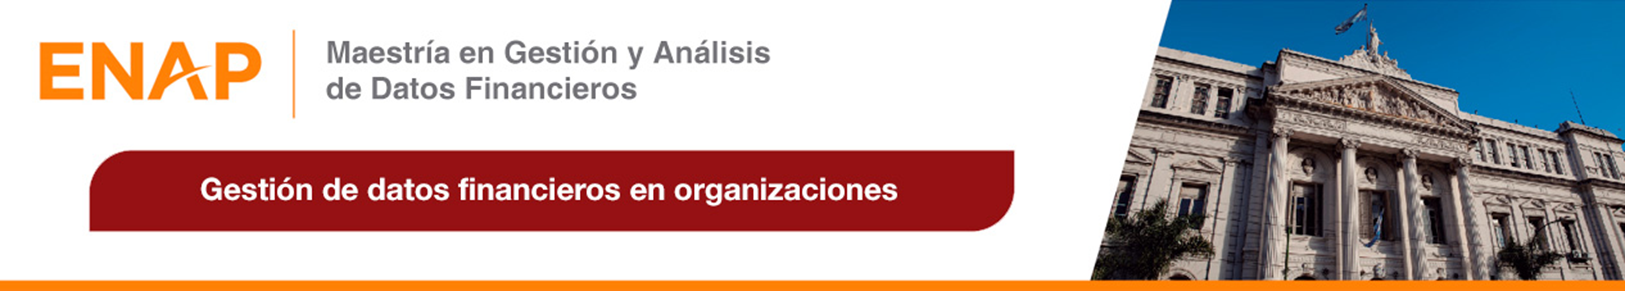

MAESTRÍA EN GESTIÓN Y ANÁLISIS DE DATOS FINANCIEROS
# GESTIÓN DE DATOS FINANCIEROS EN ORGANIZACIONES

Profesora: Dra. Natalia Salaberry

Alumna: Sol Nalú De la Fuente Riva

**SEGUNDA INSTANCIA DE EVALUACIÓN**

## Descripción del dataset

El conjunto de datos corresponde a información operativa de una entidad que otorga créditos, con cinco tablas: Contacto (clientes), Crédito (solicitudes), Cuotas (detalle de cuotas), Caja y banco (extractos) y Cobros (pagos).

## 0. Importación de librerías

In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
sns.set()
rand_state = 42
C_ACRED = '#0E7C86'
C_RECH = '#D97706'
C_OTROS = '#94A3B8'
C_IMPORTANCE = '#1E3A5F'

## 1. Obtención de datos

Si no se encuentran los archivos originales de Masori en `data_original/` (por ejemplo, al ejecutar este notebook desde el repositorio público, sin acceso a los datos crudos), el notebook carga directamente los datos ya anonimizados desde `data_anonimizada/` y omite las celdas de anonimización propiamente dicha, así como las dos celdas de Preprocesamiento que dependen de columnas (`Número de Identificación`, `Mobile`, `Email`) que ya no existen una vez anonimizados los datos. El resto del análisis (preprocesamiento restante, EDA, riesgo de reidentificación, Privacidad Diferencial) se ejecuta igual en ambos casos.

### Obtención de los file_id


In [119]:
import os

RUTA_DATOS = "data_original"        # carpeta local con los Excel crudos de Masori
RUTA_ANONIMIZADA = "data_anonimizada"  # carpeta con los Excel ya anonimizados

DATOS_ORIGINALES_DISPONIBLES = os.path.exists(f"{RUTA_DATOS}/Contacto.xlsx")



#### Contacto

In [120]:
if DATOS_ORIGINALES_DISPONIBLES:
    contacto = pd.read_excel(f"{RUTA_DATOS}/Contacto.xlsx")
else:
    contacto = pd.read_excel(f"{RUTA_ANONIMIZADA}/Contacto_anonimizado.xlsx")


#### Crédito

In [121]:
if DATOS_ORIGINALES_DISPONIBLES:
    credito = pd.read_excel(f"data_original\Crédito.xlsx")
else:
    credito = pd.read_excel(f"{RUTA_ANONIMIZADA}/Credito_anonimizado.xlsx")


#### Cuotas

In [122]:
if DATOS_ORIGINALES_DISPONIBLES:
    cuotas = pd.read_excel(f"data_original\Cuotas.xlsx")
else:
    cuotas = pd.read_excel(f"{RUTA_ANONIMIZADA}/Cuotas_anonimizado.xlsx")


#### Caja y banco

In [123]:
if DATOS_ORIGINALES_DISPONIBLES:
    caja = pd.read_excel(f"data_original/Caja.xlsx")
else:
    caja = pd.read_excel(f"{RUTA_ANONIMIZADA}/Caja_anonimizado.xlsx")


#### Cobros


In [124]:
if DATOS_ORIGINALES_DISPONIBLES:
    cobros = pd.read_excel(f"data_original/Cobros.xlsx")
else:
    cobros = pd.read_excel(f"{RUTA_ANONIMIZADA}/Cobros_anonimizado.xlsx")


### Filtros de calidad de dato

Se excluyen registros que generan duplicación de créditos pre-cancelados: cuotas con Estado de
cuota = "Precancelado", y créditos con Plantilla = "Crédito auxiliar".

In [125]:
cuotas = cuotas[cuotas["Estado de cuota"] != "Precancelado"].copy()

credito = credito[credito["Plantilla"] != "Crédito auxiliar"].copy()


## 2. Preprocesamiento inicial

### Calidad de datos y tratamiento de valores faltantes

In [126]:
# Contacto
print("--- Contacto ---")
print(contacto.info())
print()
print("Nulos por columna:")
print(contacto.isnull().sum())
print()
print(f"Filas duplicadas: {contacto.duplicated().sum()}")


--- Contacto ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127 entries, 0 to 126
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Creado el          127 non-null    datetime64[ns]
 1   State              24 non-null     object        
 2   Saldo              64 non-null     float64       
 3   Saldo vencido      9 non-null      float64       
 4   Creditos activos   127 non-null    int64         
 5   Estado             127 non-null    object        
 6   Cliente_id         127 non-null    object        
 7   Identificacion_id  127 non-null    object        
 8   Mobile_id          127 non-null    object        
 9   Email_id           127 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 10.1+ KB
None

Nulos por columna:
Creado el              0
State                103
Saldo                 63
Saldo vencido        118
Creditos ac

In [127]:
# Crédito
print("--- Crédito ---")
print(credito.info())
print()
print("Nulos por columna:")
print(credito.isnull().sum())
print()
print(f"Filas duplicadas: {credito.duplicated().sum()}")


--- Crédito ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Fecha                 189 non-null    datetime64[ns]
 1   Nombre                189 non-null    object        
 2   Categoría de crédito  189 non-null    object        
 3   Linea de crédito      144 non-null    object        
 4   Usuario               189 non-null    object        
 5   Monto                 183 non-null    float64       
 6   Plantilla             107 non-null    object        
 7   Cuotas activas        189 non-null    int64         
 8   Saldo                 77 non-null     float64       
 9   Estado                189 non-null    object        
 10  otorgado              189 non-null    object        
 11  Cliente_id            189 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(8)
memory u

In [128]:
# Cuotas
print("--- Cuotas ---")
print(cuotas.info())
print()
print("Nulos por columna:")
print(cuotas.isnull().sum())
print()
print(f"Filas duplicadas: {cuotas.duplicated().sum()}")


--- Cuotas ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149 entries, 0 to 1148
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Nro. Cuota                   1149 non-null   int64         
 1   Crédito                      1149 non-null   object        
 2   Nombre de cuota              1149 non-null   object        
 3   Fecha de vencimiento         1149 non-null   datetime64[ns]
 4   Tipo de periodo              1149 non-null   object        
 5   Capital                      1148 non-null   float64       
 6   Interés                      1144 non-null   float64       
 7   Seguro                       0 non-null      float64       
 8   Cargo                        1109 non-null   float64       
 9   Impuesto                     1145 non-null   float64       
 10  Total                        1149 non-null   float64       
 11  Otros conceptos - Monto     

In [129]:
# Caja y banco
print("--- Caja y banco ---")
print(caja.info())
print()
print("Nulos por columna:")
print(caja.isnull().sum())
print()
print(f"Filas duplicadas: {caja.duplicated().sum()}")


--- Caja y banco ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Nombre            21 non-null     object        
 1   Fecha             21 non-null     datetime64[ns]
 2   Diario            21 non-null     object        
 3   Usuario           21 non-null     object        
 4   Saldo inicial     14 non-null     float64       
 5   Saldo final real  14 non-null     float64       
 6   Estado            21 non-null     object        
dtypes: datetime64[ns](1), float64(2), object(4)
memory usage: 1.3+ KB
None

Nulos por columna:
Nombre              0
Fecha               0
Diario              0
Usuario             0
Saldo inicial       7
Saldo final real    7
Estado              0
dtype: int64

Filas duplicadas: 0


In [130]:
# Cobros
print("--- Cobros ---")
print(cobros.info())
print()
print("Nulos por columna:")
print(cobros.isnull().sum())
print()
print(f"Filas duplicadas: {cobros.duplicated().sum()}")


--- Cobros ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 648 entries, 0 to 647
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Fecha de cobro   648 non-null    datetime64[ns]
 1   Name             648 non-null    object        
 2   Metodo de cobro  645 non-null    object        
 3   Monto a cobrar   603 non-null    float64       
 4   Estado           648 non-null    object        
 5   Cliente_id       648 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 30.5+ KB
None

Nulos por columna:
Fecha de cobro      0
Name                0
Metodo de cobro     3
Monto a cobrar     45
Estado              0
Cliente_id          0
dtype: int64

Filas duplicadas: 0


#### Crédito

In [131]:
credito[credito["Saldo"].isnull()]["Estado"].value_counts()


Estado
Rechazado        76
Pagado           29
Refinanciado      3
Pre-cancelado     3
Borrador          1
Name: count, dtype: int64

La gran mayoria de los Saldo nulos corresponde a creditos Rechazado (76), Pagado (29), Refinanciado (3) o Pre-cancelado (3), todos casos donde no corresponde tener saldo pendiente (o nunca se desembolso, o ya se cancelo por completo). 

In [132]:
credito[credito["Linea de crédito"].isnull()]["Estado"].value_counts()


Estado
Rechazado    45
Name: count, dtype: int64

Los 45 nulos de Linea de credito corresponden todos a creditos Rechazado (tiene sentido que a una solicitud rechazada nunca se le haya asignado una linea de producto).

In [133]:
credito[credito['Plantilla'].isnull()]['Linea de crédito'].value_counts()

Linea de crédito
Descuento de cheques    33
Crédito personal         4
Name: count, dtype: int64

In [134]:
credito[(credito['Plantilla'].isnull()) & (credito['Linea de crédito'] == 'Crédito personal')]['Estado'].value_counts()

Estado
Rechazado    4
Name: count, dtype: int64

Los nulos de Plantilla se concentran en Descuento de cheques (linea sin plantilla propia) y en créditos personales rechazados, que se entiende que no hayan llegado a que se le asigne una plantilla. 

#### Contacto

In [135]:
contacto[contacto['State'].isnull()]['Estado'].value_counts()

Estado
Aprobado    66
Borrador    29
Revisión     8
Name: count, dtype: int64

La ausencia de State se reparte de forma similar entre las categorías de Estado del contacto, por lo que no depende de si el contacto fue aprobado o no, sino de una variable con baja tasa de carga en general.

In [136]:
contacto[contacto['Saldo'].isnull()]['Estado'].value_counts()

Estado
Borrador    31
Aprobado    30
Revisión     2
Name: count, dtype: int64

In [137]:
contacto[contacto['Saldo vencido'].isnull()]['Estado'].value_counts()

Estado
Aprobado    79
Borrador    31
Revisión     8
Name: count, dtype: int64

Los Aprobado con Saldo vencido nulo siguen debiendo (tienen Saldo positivo) pero no tienen mora calculada; en Borrador todavía no corresponde tener saldo vencido por no estar aprobados; en Revisión ocurre que simplemente no tiene saldo vencido.

In [138]:
if DATOS_ORIGINALES_DISPONIBLES:
    display(contacto[contacto['Número de Identificación'].isnull()]['Estado'].value_counts())
else:
    print("Celda omitida: 'Número de Identificación' ya fue reemplazada por 'Identificacion_id'.")

Celda omitida: 'Número de Identificación' ya fue reemplazada por 'Identificacion_id'.


Los pocos nulos de Número de Identificación corresponden exclusivamente a contactos en Borrador, coherente con que un registro todavía no confirmado carezca de la documentación completa.

In [139]:
if DATOS_ORIGINALES_DISPONIBLES:
    print(contacto[contacto['Mobile'].isnull()]['Estado'].value_counts())
    print(contacto[contacto['Email'].isnull()]['Estado'].value_counts())
else:
    print("Celda omitida: 'Mobile' y 'Email' ya fueron reemplazadas por 'Mobile_id' y 'Email_id'.")

Celda omitida: 'Mobile' y 'Email' ya fueron reemplazadas por 'Mobile_id' y 'Email_id'.


Los nulos de Mobile y de Email son escasos y no muestran un patrón asociado al Estado; se interpretan como datos de contacto simplemente no informados al momento de la carga.

#### Cuotas

In [140]:
cuotas[cuotas["Cuota - Pagado"].isnull()]["Estado de cuota"].value_counts()


Estado de cuota
Activa          583
Refinanciado     49
Pagado            2
Name: count, dtype: int64

La mayoria de los nulos de Cuota - Pagado corresponde a cuotas Activa (583), es decir, todavia no vencieron ni se pagaron, por lo que es esperable que no tengan un pago registrado. Tambien aparecen 49 Refinanciado. Hay 2 casos con Estado de cuota Pagado y Cuota - Pagado nulo, que si son una inconsistencia real.

In [141]:
cuotas[cuotas['Cuota - Saldo'].isnull()]['Estado de cuota'].value_counts()

Estado de cuota
Pagado    503
Name: count, dtype: int64

Los nulos de Cuota - Saldo corresponden en su totalidad a cuotas Pagado, coherente con que una cuota ya cancelada no tenga saldo pendiente.

#### Cobros

In [142]:
cobros[cobros['Metodo de cobro'].isnull()]['Estado'].value_counts()

Estado
Borrador    3
Name: count, dtype: int64

Los nulos de Método de cobro corresponden exclusivamente a cobros en estado Borrador, coherente con que un registro todavía no confirmado carezca de esa información.

In [143]:
cobros[cobros['Monto a cobrar'].isnull()]['Estado'].value_counts()

Estado
Borrador     43
Cancelado     2
Name: count, dtype: int64

Los nulos de Monto a cobrar se concentran casi en su totalidad en cobros Borrador, con dos casos adicionales en Cancelado, ambos coherentes con registros que no llegaron a efectivizarse.

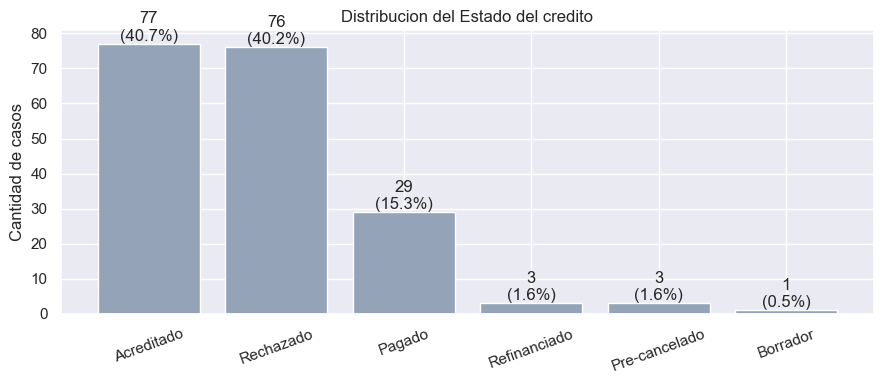

In [144]:
vc = credito['Estado'].value_counts()

plt.figure(figsize=(9, 4))
bars = plt.bar(vc.index, vc.values, color=C_OTROS)
for i, v in enumerate(vc.values):
    plt.text(i, v, f'{v}\n({v/len(credito):.1%})', ha='center', va='bottom')
plt.title('Distribucion del Estado del credito')
plt.ylabel('Cantidad de casos')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Acreditado y Rechazado concentran la mayoría de las solicitudes con frecuencia similar; el resto son categorías residuales.

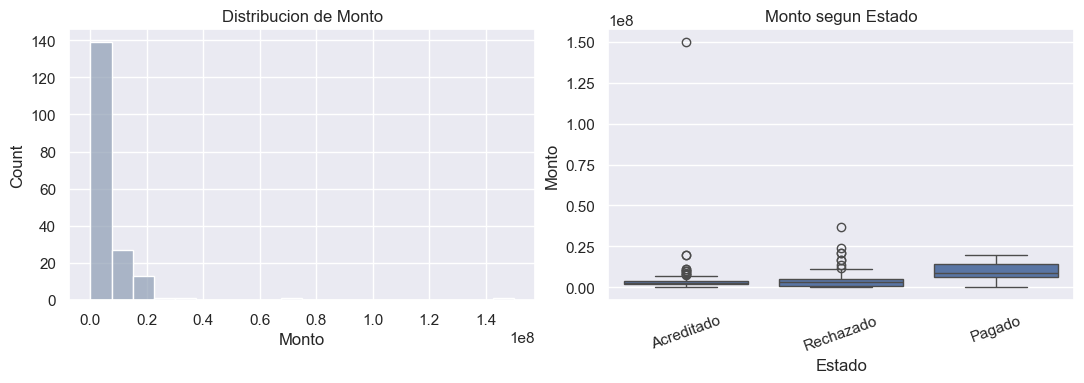

In [145]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(data=credito.dropna(subset=['Monto']), x='Monto', bins=20, color=C_OTROS, ax=ax[0])
ax[0].set_title('Distribucion de Monto')

sns.boxplot(x='Estado', y='Monto', data=credito[credito['Estado'].isin(['Acreditado', 'Rechazado', 'Pagado'])], ax=ax[1])
ax[1].set_title('Monto segun Estado')
ax[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

Monto está sesgado a la derecha, con la mayoría de los valores bajos y algún caso extremo. Las medianas de Acreditado y Rechazado son similares, por lo que Monto solo no separa bien ambos grupos.

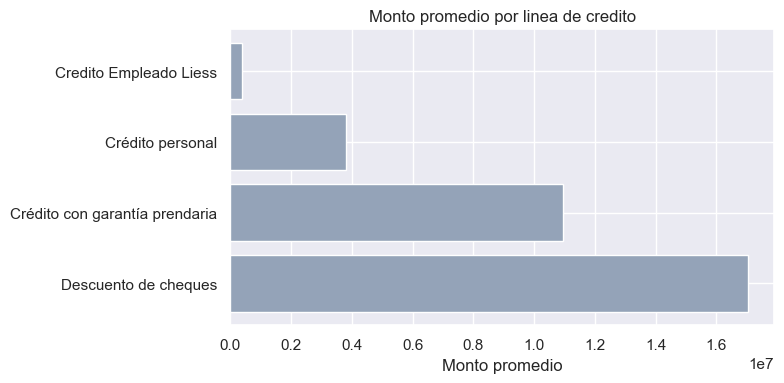

In [146]:
monto_por_linea = credito.groupby('Linea de crédito')['Monto'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(monto_por_linea.index, monto_por_linea.values, color=C_OTROS)
plt.title('Monto promedio por linea de credito')
plt.xlabel('Monto promedio')
plt.tight_layout()
plt.show()

Descuento de cheques y Crédito con garantía prendaria tienen los montos promedio más altos, coherente con respaldar operaciones mayores que un crédito personal.

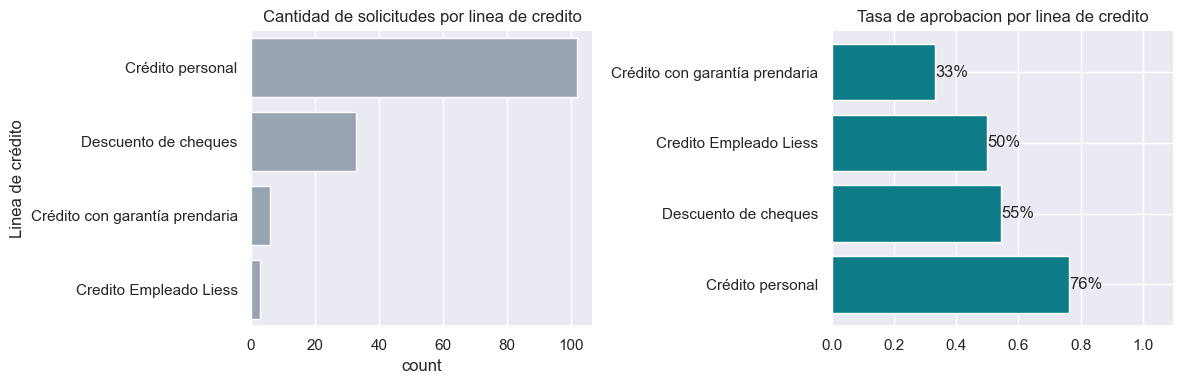

In [147]:
tasa_aprobacion = (
    credito[credito['Estado'].isin(['Acreditado', 'Rechazado'])]
    .groupby('Linea de crédito')['Estado']
    .apply(lambda s: (s == 'Acreditado').mean())
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=credito, y='Linea de crédito', order=credito['Linea de crédito'].value_counts().index, color=C_OTROS, ax=ax[0])
ax[0].set_title('Cantidad de solicitudes por linea de credito')

ax[1].barh(tasa_aprobacion.index, tasa_aprobacion.values, color=C_ACRED)
for i, v in enumerate(tasa_aprobacion.values):
    ax[1].text(v, i, f'{v:.0%}', va='center')
ax[1].set_title('Tasa de aprobacion por linea de credito')
ax[1].set_xlim(0, 1.1)
plt.tight_layout()
plt.show()

Crédito personal concentra la mayor cantidad de solicitudes con aprobación intermedia. Descuento de cheques tiene la aprobación más baja pese a su volumen; Crédito con garantía prendaria, la más alta con bajo volumen.

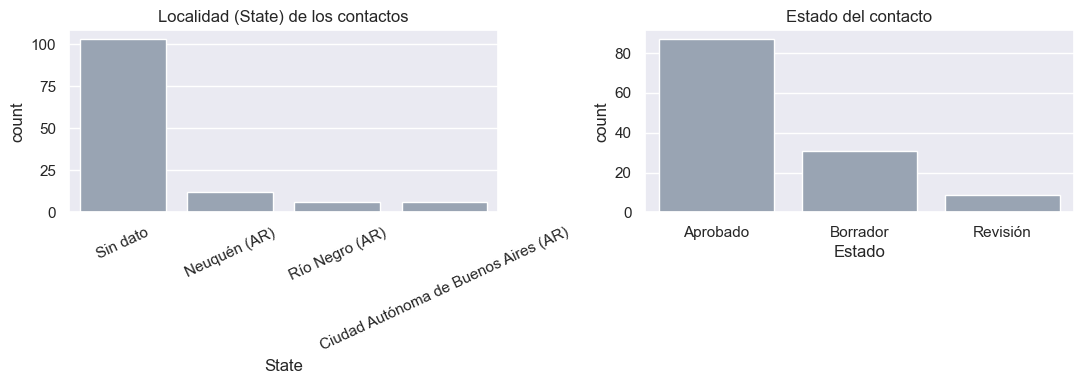

In [148]:
contacto_graf = contacto.copy()
contacto_graf['State'] = contacto_graf['State'].fillna('Sin dato')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(data=contacto_graf, x='State', order=contacto_graf['State'].value_counts().index, color=C_OTROS, ax=ax[0])
ax[0].set_title('Localidad (State) de los contactos')
ax[0].tick_params(axis='x', rotation=25)

sns.countplot(data=contacto_graf, x='Estado', order=contacto_graf['Estado'].value_counts().index, color=C_OTROS, ax=ax[1])
ax[1].set_title('Estado del contacto')
plt.tight_layout()
plt.show()

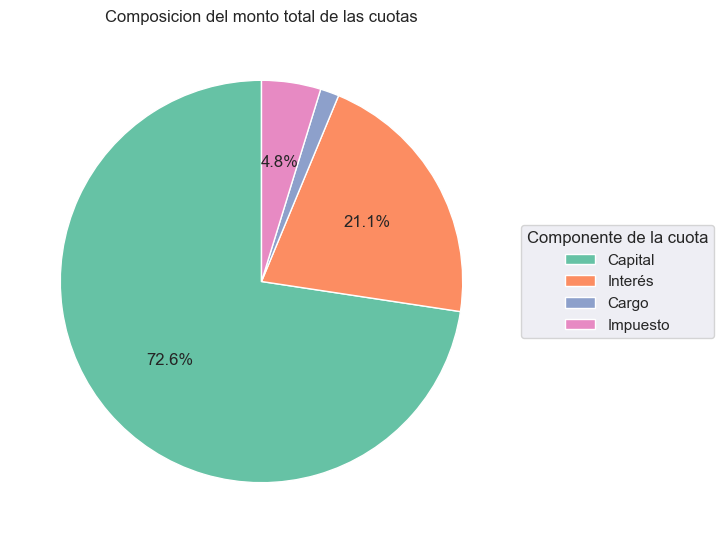

In [149]:
# torta: composicion de la cuota (Capital, Interes, Cargo, Impuesto)
comp_cuota = cuotas[['Capital', 'Interés', 'Cargo', 'Impuesto']].sum()

def autopct_min(pct):
        return f'{pct:.1f}%' if pct >= 4 else ''

plt.figure(figsize=(7, 6))
wedges, _, autotexts = plt.pie(
    comp_cuota.values, autopct=autopct_min,
    colors=sns.color_palette('Set2', len(comp_cuota)), startangle=90,
)
plt.legend(
    wedges, comp_cuota.index, title='Componente de la cuota',
    loc='center left', bbox_to_anchor=(1, 0.5),
)
plt.title('Composicion del monto total de las cuotas')
plt.tight_layout()
plt.show()

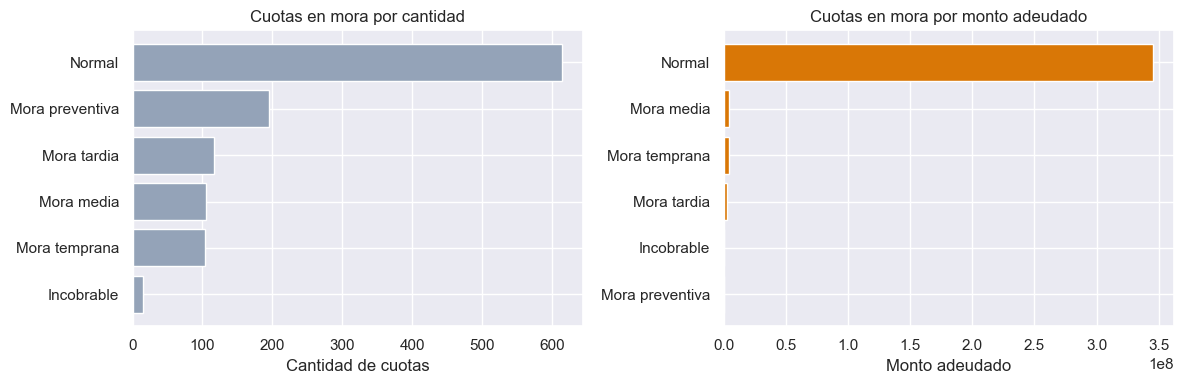

In [150]:
# comparacion de mora: cantidad de cuotas vs monto adeudado, por estado de mora
cantidad_mora = cuotas['Estado de mora'].value_counts().sort_values()
monto_mora = cuotas.groupby('Estado de mora')['Cuota - Saldo'].sum().sort_values()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].barh(cantidad_mora.index, cantidad_mora.values, color=C_OTROS)
ax[0].set_title('Cuotas en mora por cantidad')
ax[0].set_xlabel('Cantidad de cuotas')

ax[1].barh(monto_mora.index, monto_mora.values, color=C_RECH)
ax[1].set_title('Cuotas en mora por monto adeudado')
ax[1].set_xlabel('Monto adeudado')

plt.tight_layout()
plt.show()

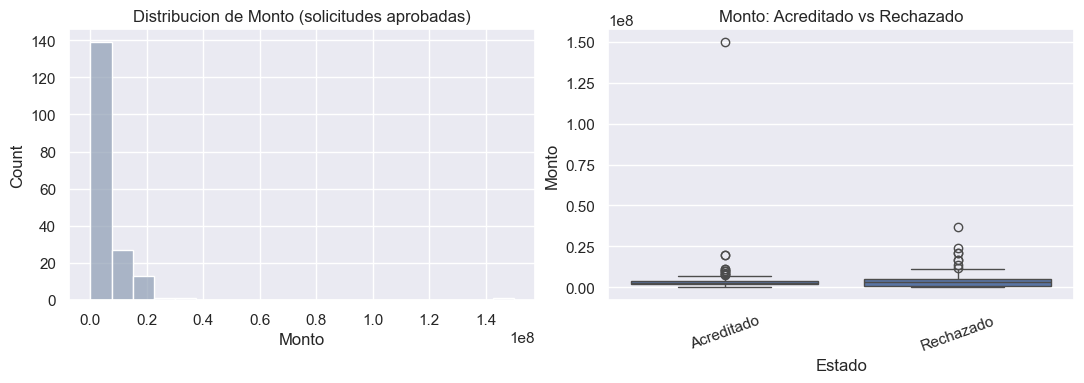

In [151]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

resueltas = credito[credito['Estado'] != 'Borrador'].dropna(subset=['Monto'])
sns.histplot(data=resueltas, x='Monto', bins=20, color=C_OTROS, ax=ax[0])
ax[0].set_title('Distribucion de Monto (solicitudes aprobadas)')

sns.boxplot(x='Estado', y='Monto', data=credito[credito['Estado'].isin(['Acreditado', 'Rechazado'])], ax=ax[1])
ax[1].set_title('Monto: Acreditado vs Rechazado')
ax[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

In [152]:
# Porcentaje de cuotas en mora, medido por cantidad y por monto
total_cuotas = len(cuotas)
total_saldo = cuotas["Cuota - Saldo"].sum()

cuotas_en_mora = cuotas[cuotas["Estado de mora"] != "Normal"]

pct_mora_cantidad = len(cuotas_en_mora) / total_cuotas * 100
pct_mora_monto = cuotas_en_mora["Cuota - Saldo"].sum() / total_saldo * 100

print(f"Cuotas en mora por cantidad: {pct_mora_cantidad:.2f}%")
print(f"Cuotas en mora por monto (saldo): {pct_mora_monto:.2f}%")

Cuotas en mora por cantidad: 46.56%
Cuotas en mora por monto (saldo): 3.36%


## 3.Anonimización de identificadores directos

In [153]:
!pip install -U -q anonymizedf
from anonymizedf.anonymizedf import anonymize


In [154]:
if DATOS_ORIGINALES_DISPONIBLES:
    # 1. Se arma un mapa único de nombres reales-seudónimo, para que el mismo cliente
    #    tenga el mismo código en contacto, credito, cuotas y cobros.
    nombres_unicos = pd.unique(pd.concat([
        contacto["Nombre"].dropna(),
        credito["Cliente"].dropna(),
        cuotas["Empresa"].dropna(),
        cobros["Cliente"].dropna(),
    ]))

    mapa_nombres = pd.DataFrame({"nombre_real": nombres_unicos})
    an_mapa = anonymize(mapa_nombres)
    an_mapa.fake_ids("nombre_real")  # crea la columna 'Fake_nombre_real'

    diccionario_seudonimos = dict(zip(mapa_nombres["nombre_real"], mapa_nombres["Fake_nombre_real"]))
    print(f"Clientes únicos identificados y seudonimizados: {len(diccionario_seudonimos)}")
else:
    print("Celda omitida: los datos cargados ya vienen anonimizados (Cliente_id ya existe).")

Celda omitida: los datos cargados ya vienen anonimizados (Cliente_id ya existe).


In [155]:
if DATOS_ORIGINALES_DISPONIBLES:
    # 2. Se aplica el mapa de seudónimos y se eliminan las columnas con nombres reales
    contacto["Cliente_id"] = contacto["Nombre"].map(diccionario_seudonimos)
    credito["Cliente_id"]  = credito["Cliente"].map(diccionario_seudonimos)
    cuotas["Cliente_id"]   = cuotas["Empresa"].map(diccionario_seudonimos)
    cobros["Cliente_id"]   = cobros["Cliente"].map(diccionario_seudonimos)

    contacto = contacto.drop(columns=["Nombre"])
    credito  = credito.drop(columns=["Cliente"])
    cuotas   = cuotas.drop(columns=["Empresa"])
    cobros   = cobros.drop(columns=["Cliente"])
else:
    print("Celda omitida (ver celda anterior).")

Celda omitida (ver celda anterior).


In [156]:
if DATOS_ORIGINALES_DISPONIBLES:
    # 3. Se anonimiza el CUIT/CUIL, el telefono y el email de 'contacto'.
    an_contacto = anonymize(contacto)
    an_contacto.fake_ids("Número de Identificación")
    an_contacto.fake_ids("Mobile")
    an_contacto.fake_ids("Email")

    contacto = contacto.drop(columns=["Número de Identificación", "Mobile", "Email"])
    contacto = contacto.rename(columns={
        "Fake_Número de Identificación": "Identificacion_id",
        "Fake_Mobile": "Mobile_id",
        "Fake_Email": "Email_id",
    })
else:
    print("Celda omitida (ver celdas anteriores).")

contacto.head()

Celda omitida (ver celdas anteriores).


,Creado el,State,Saldo,Saldo vencido,Creditos activos,Estado,Cliente_id,Identificacion_id,Mobile_id,Email_id
0,2025-11-12 15:03:13,Río Negro (AR),8593392.95,NaN,1,Aprobado,RYTV64750094288272,ITYP66728380702313,QMDK40625308594480,LIRM81220073544442
1,2026-04-09 09:36:25,NaN,1490875.00,NaN,1,Aprobado,LOQX44061688419571,TBLZ56332001533986,JNRC03753049185969,LIXH05116685131188
2,2025-12-21 08:26:08,NaN,495437.34,NaN,1,Aprobado,EOVF71678305104413,UHEP81057545466833,HYLJ04961485341352,MOCR91250556321384
3,2026-08-11 10:48:46,NaN,NaN,NaN,0,Borrador,VJWE89203014463285,YEXX87418549606169,ZHAR50143282878262,CAXP56205790931086
4,2025-12-17 19:25:40,NaN,1068885.92,NaN,2,Aprobado,MHOM62049143276771,ODYV58335293625631,ALLZ25842988591516,JMFH11222718211032


Los datos ya anonimizados (identificadores directos, telefono y email reemplazados por seudonimos) se guardan en una carpeta local separada. 

In [157]:
if DATOS_ORIGINALES_DISPONIBLES:
    os.makedirs("data_anonimizada", exist_ok=True)

    contacto.to_excel("data_anonimizada/Contacto_anonimizado.xlsx", index=False)
    credito.to_excel("data_anonimizada/Credito_anonimizado.xlsx", index=False)
    cuotas.to_excel("data_anonimizada/Cuotas_anonimizado.xlsx", index=False)
    caja.to_excel("data_anonimizada/Caja_anonimizado.xlsx", index=False)
    cobros.to_excel("data_anonimizada/Cobros_anonimizado.xlsx", index=False)

    print("Datos anonimizados guardados en la carpeta data_anonimizada/")
else:
    print("Celda omitida: ya se estan usando los datos de data_anonimizada/, no hace falta volver a exportarlos.")

Celda omitida: ya se estan usando los datos de data_anonimizada/, no hace falta volver a exportarlos.


### 3.3 Gráficos del tablero

In [158]:
def formato_ars(x, decimales=0):
    s = f"{x:,.{decimales}f}"
    return "$ " + s.replace(",", "X").replace(".", ",").replace("X", ".")

FONDO          = "#0D0D0D"
NEGRO          = "#000000"
BLANCO         = "#FFFFFF"
NARANJA        = "#F97316"
NARANJA_CLARO  = "#FDBA74"
NARANJA_OSCURO = "#C2410C"
GRIS           = "#9CA3AF"
GRIS_CLARO     = "#D1D5DB"
GRIS_OSCURO    = "#6B7280"
GRID_COLOR     = "#2B2B2B"

PALETA_CATEGORICA = [BLANCO, NARANJA, GRIS, NARANJA_CLARO, GRIS_CLARO, NARANJA_OSCURO, GRIS_OSCURO]

C_PRIMARY   = BLANCO
C_SECONDARY = GRIS
C_ALERT     = NARANJA
C_RISK      = NARANJA_OSCURO
C_NEUTRAL   = GRIS_OSCURO

AZUL_OSCURO = BLANCO
PLANTILLA = "plotly_dark"

def tema_oscuro(fig, **kwargs):
    legend_kwargs = kwargs.pop("legend", {})
    legend_final = dict(bgcolor=FONDO, font=dict(color=BLANCO))
    legend_final.update(legend_kwargs)

    titulo_kwargs = kwargs.pop("title", None)
    if titulo_kwargs is not None:
        if isinstance(titulo_kwargs, str):
            titulo_kwargs = {"text": titulo_kwargs}
        if "text" in titulo_kwargs and not titulo_kwargs["text"].startswith("<b>"):
            titulo_kwargs["text"] = f"<b>{titulo_kwargs['text']}</b>"
        titulo_kwargs.setdefault("x", 0.5)

    fig.update_layout(
        template=PLANTILLA,
        plot_bgcolor=FONDO, paper_bgcolor=FONDO,
        font=dict(color=BLANCO, family="Arial"),
        title_font=dict(color=BLANCO, family="Arial"),
        legend=legend_final,
        separators=",.",
        **({"title": titulo_kwargs} if titulo_kwargs is not None else {}),
        **kwargs,
    )
    fig.update_xaxes(gridcolor=GRID_COLOR, zerolinecolor=GRID_COLOR, color=BLANCO)
    fig.update_yaxes(gridcolor=GRID_COLOR, zerolinecolor=GRID_COLOR, color=BLANCO)
    # titulos de subplots (subplot_titles) tambien en negrita y centrados
    fig.for_each_annotation(lambda a: a.update(text=f"<b>{a.text}</b>") if a.text and not a.text.startswith("<b>") else None)
    return fig

#### Distribución de variables numéricas

In [159]:
credito_valido = credito.dropna(subset=["Nombre"]).copy()

fig = make_subplots(rows=1, cols=2, subplot_titles=("Monto por línea de crédito", "Monto por estado"))

orden_linea_box = credito_valido.groupby("Linea de crédito")["Monto"].median().sort_values().index
for i, linea in enumerate(orden_linea_box):
    datos = credito_valido.loc[credito_valido["Linea de crédito"] == linea, "Monto"]
    fig.add_trace(go.Box(y=datos, name=linea, marker_color=PALETA_CATEGORICA[i % len(PALETA_CATEGORICA)],
                          line_color=BLANCO, showlegend=False), row=1, col=1)

orden_estado_box = credito_valido.groupby("Estado")["Monto"].median().sort_values().index
for i, estado in enumerate(orden_estado_box):
    datos = credito_valido.loc[credito_valido["Estado"] == estado, "Monto"]
    fig.add_trace(go.Box(y=datos, name=estado, marker_color=PALETA_CATEGORICA[i % len(PALETA_CATEGORICA)],
                          line_color=BLANCO, showlegend=False), row=1, col=2)

fig.update_yaxes(tickformat=",.0f", title_text="Monto", row=1, col=1)
fig.update_yaxes(tickformat=",.0f", row=1, col=2)
tema_oscuro(fig, height=480)
fig.show()


In [160]:
monto_total_linea = credito_valido.groupby("Linea de crédito")["Monto"].sum().sort_values()
monto_total_estado = credito_valido.groupby("Estado")["Monto"].sum().sort_values()

fig = make_subplots(rows=1, cols=2, subplot_titles=("Monto total por línea de crédito", "Monto total por estado"))

fig.add_trace(go.Bar(x=monto_total_linea.values, y=monto_total_linea.index, orientation="h",
                      marker_color=[PALETA_CATEGORICA[i % len(PALETA_CATEGORICA)] for i in range(len(monto_total_linea))],
                      showlegend=False, hovertemplate="%{y}: %{x:,.0f}<extra></extra>"), row=1, col=1)
fig.add_trace(go.Bar(x=monto_total_estado.values, y=monto_total_estado.index, orientation="h",
                      marker_color=[PALETA_CATEGORICA[i % len(PALETA_CATEGORICA)] for i in range(len(monto_total_estado))],
                      showlegend=False, hovertemplate="%{y}: %{x:,.0f}<extra></extra>"), row=1, col=2)

fig.update_xaxes(title_text="Monto total", tickformat=",.0f", row=1, col=1)
fig.update_xaxes(title_text="Monto total", tickformat=",.0f", row=1, col=2)
tema_oscuro(fig, height=420)
fig.show()


#### Variables categóricas

In [161]:
resumen_linea = credito_valido.groupby("Linea de crédito").agg(
    Monto=("Monto", "sum"),
    Cantidad=("Nombre", "count"),
).sort_values("Monto", ascending=False).reset_index()

fig = px.pie(resumen_linea, values="Monto", names="Linea de crédito",
             custom_data=["Cantidad"])

fig.update_layout(legend_title_text="Línea de crédito")
fig.update_layout(title="Cartera por línea de crédito")
fig.update_layout(title_x=0.5)
fig.update_layout(title_font_family="Arial", title_font_size=22, title_font_color=BLANCO, title_font_weight="bold")

fig.update_traces(
    hovertemplate=(
        "<b>Línea de crédito:</b> %{label}<br>" +
        "<b>Monto:</b> %{value:,.0f}<br>" +
        "<b>Cantidad de créditos:</b> %{customdata[0]}<br>" +
        "<b>% del total:</b> %{percent}<extra></extra>"
    )
)

fig.update_layout(width=650, height=650, plot_bgcolor=FONDO, paper_bgcolor=FONDO, font=dict(color=BLANCO), separators=",.")
fig.update_traces(marker=dict(colors=PALETA_CATEGORICA, line=dict(color=FONDO, width=2)))
fig.show()


In [162]:
orden_estado = credito_valido["Estado"].value_counts()
monto_estado = credito_valido.groupby("Estado")["Monto"].sum().reindex(orden_estado.index).sort_values()
cantidad_estado = orden_estado.reindex(monto_estado.index)

colores_estado = {
    "Acreditado": BLANCO, "Pagado": GRIS, "Refinanciado": NARANJA,
    "Pre-cancelado": GRIS_CLARO, "Borrador": NARANJA_CLARO, "Rechazado": NARANJA_OSCURO,
}
cols = [colores_estado.get(e, GRIS) for e in monto_estado.index]

fig = go.Figure(go.Bar(
    x=monto_estado.values, y=monto_estado.index, orientation="h", marker_color=cols,
    customdata=cantidad_estado.values,
    hovertemplate="<b>%{y}</b><br>Monto: %{x:,.0f}<br>Cantidad: %{customdata} créditos<extra></extra>",
))
tema_oscuro(fig, height=380, title=dict(text="Créditos por estado: monto y cantidad"))
fig.update_xaxes(title_text="Monto", tickformat=",.0f")
fig.show()


In [163]:
orden_mora = cuotas["Estado de mora"].value_counts()
monto_mora = cuotas.groupby("Estado de mora")["Cuota - Saldo"].sum().reindex(orden_mora.index).sort_values()
cantidad_mora = orden_mora.reindex(monto_mora.index)

colores_mora = {
    "Normal": BLANCO, "Mora temprana": NARANJA_CLARO, "Mora media": NARANJA,
    "Mora tardia": NARANJA_OSCURO, "Incobrable": "#7C2D12", "Mora preventiva": GRIS,
}
cols2 = [colores_mora.get(e, GRIS) for e in monto_mora.index]

fig = go.Figure(go.Bar(
    x=monto_mora.values, y=monto_mora.index, orientation="h", marker_color=cols2,
    customdata=cantidad_mora.values,
    hovertemplate="<b>%{y}</b><br>Saldo: %{x:,.0f}<br>Cantidad: %{customdata} cuotas<extra></extra>",
))
tema_oscuro(fig, height=420, title=dict(text="Cuotas por estado de mora: saldo y cantidad"))
fig.update_xaxes(title_text="Saldo", tickformat=",.0f")
fig.show()


####  Evolución mensual del origen de crédito

In [164]:
# Solo créditos efectivamente otorgados (excluye Rechazado y Borrador, que nunca implicaron desembolso real)
ESTADOS_OTORGADOS = ["Acreditado", "Pagado", "Refinanciado", "Pre-cancelado"]
credito_otorgado = credito_valido[credito_valido["Estado"].isin(ESTADOS_OTORGADOS)].copy()

credito_otorgado["Fecha"] = pd.to_datetime(credito_otorgado["Fecha"])
credito_otorgado["Mes"] = credito_otorgado["Fecha"].dt.to_period("M").dt.to_timestamp()

evolucion = credito_otorgado.groupby(["Mes", "Linea de crédito"])["Monto"].sum().unstack(fill_value=0)
evolucion_acumulada = evolucion.sum(axis=1).cumsum()

fig = go.Figure()
for i, linea in enumerate(evolucion.columns):
    color = PALETA_CATEGORICA[i % len(PALETA_CATEGORICA)]
    fig.add_trace(go.Scatter(
        x=evolucion.index, y=evolucion[linea],
        name=linea, mode="lines", stackgroup="cartera",
        line=dict(width=0.5, color=color), fillcolor=color,
        hovertemplate="%{fullData.name}<br>%{x|%b-%Y}: %{y:,.0f}<extra></extra>",
    ))

fig.add_trace(go.Scatter(
    x=evolucion_acumulada.index, y=evolucion_acumulada.values,
    name="Monto acumulado (eje derecho)", mode="lines+markers",
    line=dict(width=2, color=NARANJA, dash="dot"), marker=dict(size=5, color=NARANJA),
    yaxis="y2",
    hovertemplate="Acumulado a %{x|%b-%Y}: %{y:,.0f}<extra></extra>",
))

tema_oscuro(fig, height=520,
    title=dict(text="<b>Evolución mensual del origen de crédito, por línea</b>", font=dict(size=17)),
    xaxis=dict(title="Mes", tickformat="%b-%Y"),
    yaxis=dict(title="Monto originado por mes ($)", tickformat=",.0f"),
    yaxis2=dict(title="Monto acumulado ($)", overlaying="y", side="right", tickformat=",.0f", showgrid=False, color=BLANCO),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
fig.show()


#### Composición mensual del cronograma de cuotas

In [165]:
MESES_ES = {1:"Ene",2:"Feb",3:"Mar",4:"Abr",5:"May",6:"Jun",7:"Jul",8:"Ago",9:"Sep",10:"Oct",11:"Nov",12:"Dic"}

def mes_es(fecha):
    return f"{MESES_ES[fecha.month]}-{str(fecha.year)[2:]}"

FIN_PERIODO_ANALISIS = pd.Timestamp("2026-09-30")  

cuotas_tiempo = cuotas.copy()
cuotas_tiempo["Fecha de vencimiento"] = pd.to_datetime(cuotas_tiempo["Fecha de vencimiento"])
cuotas_tiempo["Mes"] = cuotas_tiempo["Fecha de vencimiento"].dt.to_period("M").dt.to_timestamp()


mensual = cuotas_tiempo[cuotas_tiempo["Mes"] <= FIN_PERIODO_ANALISIS].groupby("Mes")[["Capital", "Interés", "Cargo", "Impuesto"]].sum()
rango_completo = pd.date_range(mensual.index.min(), mensual.index.max(), freq="MS")
mensual = mensual.reindex(rango_completo, fill_value=0).sort_index()

totales = mensual.sum(axis=1)
porcentuales = mensual.div(totales.replace(0, pd.NA), axis=0).fillna(0) * 100

UMBRAL = 5

def etiquetas(col):
    p = porcentuales[col].values
    return [f"{v:.0f}%" if v >= UMBRAL else "" for v in p]

colores_comp = {"Capital": BLANCO, "Interés": NARANJA, "Cargo": GRIS, "Impuesto": NARANJA_CLARO}
etiquetas_mes = [mes_es(m) for m in mensual.index]

fig = go.Figure(data=[
    go.Bar(name=col, x=mensual[col], y=mensual.index, orientation="h",
           text=etiquetas(col), textposition="inside", insidetextanchor="middle",
           marker_color=colores_comp[col],
           hovertemplate=f"<b>{col}</b>: " + "%{x:,.0f}<extra></extra>")
    for col in ["Capital", "Interés", "Cargo", "Impuesto"]
])

tema_oscuro(fig,
    barmode="stack",
    title=dict(text="Composición mensual del cronograma de cuotas (sep-25 a sep-26)"),
    yaxis=dict(
        title="Mes", type="category",
        tickmode="array", tickvals=list(mensual.index), ticktext=etiquetas_mes,
        autorange="reversed",
    ),
    xaxis=dict(title="Monto", tickformat=",.0f"),
    legend_title_text="Componente",
    height=max(500, 30 * len(mensual)),
)
fig.show()


#### Evolución mensual de cobros confirmados

In [166]:
cobros_tiempo = cobros[cobros["Estado"] == "Confirmado"].copy()
cobros_tiempo["Fecha de cobro"] = pd.to_datetime(cobros_tiempo["Fecha de cobro"])
cobros_tiempo["Mes"] = cobros_tiempo["Fecha de cobro"].dt.to_period("M").dt.to_timestamp()
cobros_mensual = cobros_tiempo.groupby("Mes")["Monto a cobrar"].sum()

credito_otorgado_mensual = credito_otorgado.groupby("Mes")["Monto"].sum()

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=cobros_mensual.index, y=cobros_mensual.values, name="Cobrado (confirmado)",
    mode="lines+markers", line=dict(width=2, color=NARANJA, dash="dash"), marker=dict(size=7, color=NARANJA),
    hovertemplate="<b>Mes:</b> %{x|%b-%Y}<br><b>Cobrado:</b> %{y:,.0f}<extra></extra>",
))
fig.add_trace(go.Scatter(
    x=credito_otorgado_mensual.index, y=credito_otorgado_mensual.values, name="Crédito otorgado",
    mode="lines+markers", line=dict(width=2, color=BLANCO, dash="dot"), marker=dict(size=7, color=BLANCO),
    hovertemplate="<b>Mes:</b> %{x|%b-%Y}<br><b>Crédito otorgado:</b> %{y:,.0f}<extra></extra>",
))

fig.update_xaxes(tickformat="%b-%Y", title_text="Mes")
fig.update_yaxes(tickformat=",.0f", title_text="Monto")
tema_oscuro(fig, title=dict(text="Cobros confirmados vs. Crédito otorgado, por mes"), width=900, height=550)
fig.show()


#### Horizonte completo de vencimientos, por línea de crédito

In [167]:
cuotas_linea = cuotas.merge(
    credito_valido[["Nombre", "Linea de crédito"]], left_on="Crédito", right_on="Nombre", how="left"
)
cuotas_linea["Fecha de vencimiento"] = pd.to_datetime(cuotas_linea["Fecha de vencimiento"])
cuotas_linea["Mes"] = cuotas_linea["Fecha de vencimiento"].dt.to_period("M").dt.to_timestamp()

evol_horizonte = cuotas_linea.groupby(["Mes", "Linea de crédito"])["Cuota - Monto"].sum().unstack(fill_value=0)

fig = go.Figure()
for i, linea in enumerate(evol_horizonte.columns):
    color = PALETA_CATEGORICA[i % len(PALETA_CATEGORICA)]
    fig.add_trace(go.Scatter(
        x=evol_horizonte.index, y=evol_horizonte[linea],
        name=linea, mode="lines", stackgroup="cuotas",
        line=dict(width=0.5, color=color), fillcolor=color,
        hovertemplate="%{fullData.name}<br>%{x|%b-%Y}: %{y:,.0f}<extra></extra>",
    ))

fecha_corte = pd.Timestamp("2026-09-30")
fig.add_shape(
    type="line", xref="x", yref="paper",
    x0=fecha_corte, x1=fecha_corte, y0=0, y1=1,
    line=dict(color=BLANCO, dash="dash"),
)
fig.add_annotation(
    x=fecha_corte, y=1, xref="x", yref="paper",
    text="Fin período de análisis", showarrow=False,
    yanchor="bottom", font=dict(color=BLANCO),
)

tema_oscuro(fig, height=520,
    title=dict(text="Horizonte completo de vencimientos de cuotas, por línea (hasta 2029)"),
    xaxis=dict(title="Mes", tickformat="%b-%Y"),
    yaxis=dict(title="Monto de cuotas por mes", tickformat=",.0f"),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
fig.show()


In [168]:
def hex_a_rgba(color_hex, alpha):
    color_hex = color_hex.lstrip("#")
    r, g, b = int(color_hex[0:2], 16), int(color_hex[2:4], 16), int(color_hex[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"

NEON_CALIDO = ["#FF4500", "#E63946", "#FF7F50", "#FF9E00"]  # otorgamiento: naranja, rojo, coral
NEON_FRIO   = ["#00E5FF", "#FFFFFF", "#D1D5DB", "#6B7280"]  # vencimiento: celeste, blanco, gris claro, gris oscuro

cuotas_linea = cuotas.merge(
    credito_valido[["Nombre", "Linea de crédito"]], left_on="Crédito", right_on="Nombre", how="left"
)
cuotas_linea["Fecha de vencimiento"] = pd.to_datetime(cuotas_linea["Fecha de vencimiento"])
cuotas_linea["Mes"] = cuotas_linea["Fecha de vencimiento"].dt.to_period("M").dt.to_timestamp()
evol_horizonte = cuotas_linea.groupby(["Mes", "Linea de crédito"])["Cuota - Monto"].sum().unstack(fill_value=0)

fig = go.Figure()

def agregar_serie(x, y, color, stackgroup):
    fig.add_trace(go.Scatter(
        x=x, y=y, mode="lines", stackgroup=stackgroup, showlegend=False,
        line=dict(width=2, color=color), fillcolor=hex_a_rgba(color, 0.35),
        hovertemplate="%{x|%b-%Y}: %{y:,.0f}<extra></extra>",
    ))

colores_otorgado = {}
for i, linea in enumerate(evolucion.columns):
    color = NEON_CALIDO[i % len(NEON_CALIDO)]
    colores_otorgado[linea] = color
    agregar_serie(evolucion.index, evolucion[linea], color, "otorgado")

colores_vencimiento = {}
for i, linea in enumerate(evol_horizonte.columns):
    color = NEON_FRIO[i % len(NEON_FRIO)]
    colores_vencimiento[linea] = color
    agregar_serie(evol_horizonte.index, evol_horizonte[linea], color, "vencimientos")

fecha_corte = evolucion.index.max()  # ultimo mes con creditos efectivamente otorgados, se recalcula solo con cada corrida
fig.add_shape(
    type="line", xref="x", yref="paper",
    x0=fecha_corte, x1=fecha_corte, y0=0, y1=1,
    line=dict(color=BLANCO, dash="dash"),
)

etiquetas_txt = "<br>".join(
    [f'<span style="color:{color}">⬤</span> Vencimiento - {linea}' for linea, color in colores_vencimiento.items()]
    + [f'<span style="color:{color}">⬤</span> Otorgado - {linea}' for linea, color in colores_otorgado.items()]
)

fig.add_annotation(
    xref="paper", yref="paper", x=0.99, y=0.99, xanchor="right", yanchor="top",
    align="left", showarrow=False, text=etiquetas_txt,
    font=dict(size=9, color=BLANCO),
    bgcolor=FONDO, bordercolor=NARANJA, borderwidth=1, borderpad=4,
)

tema_oscuro(fig, height=520,
    title=dict(text="Otorgamiento mensual vs. horizonte de vencimientos, por línea de crédito"),
    xaxis=dict(title="Mes", tickformat="%b-%Y"),
    yaxis=dict(title="Monto", tickformat=",.0f"),
    showlegend=False,
)
fig.show()

#### Indicadores de gestión crediticia

#### Severidad de mora

Mide, para los clientes con saldo vencido, qué proporción de su deuda total representa ese saldo vencido.



In [169]:
clientes_con_mora = contacto[(contacto["Saldo vencido"].notna()) & (contacto["Saldo vencido"] > 0)].copy()
clientes_con_mora["severidad"] = clientes_con_mora["Saldo vencido"] / clientes_con_mora["Saldo"]

severidad_promedio = clientes_con_mora["severidad"].mean() * 100
print(f"Severidad de mora promedio: {severidad_promedio:.2f}%")
print(f"Clientes con saldo vencido: {len(clientes_con_mora)} de {len(contacto)}")

clientes_con_mora[["Cliente_id", "Saldo", "Saldo vencido", "severidad"]].sort_values("severidad", ascending=False)


Severidad de mora promedio: 29.25%
Clientes con saldo vencido: 9 de 127


,Cliente_id,Saldo,Saldo vencido,severidad
116,OGXW63234369802795,3001893.67,2418842.05,0.805772
68,DHOX20155262621661,1734881.36,995743.85,0.573955
57,UNVE22630895631464,319738.41,160875.70,0.503148
60,WDBC05718077773823,2733270.82,993916.65,0.363636
19,TNJO03162399965325,1869698.88,378823.88,0.202612
35,VOSR36380775089203,14266164.77,1346798.08,0.094405
16,XMLA60093559424053,7247905.51,623046.88,0.085962
126,PTDM61257971723924,1867540.95,3947.20,0.002114
43,ODNS24560269772384,11135060.78,5360.16,0.000481


#### Concentración de cartera por línea de crédito

Distribución de la cartera por línea de producto, mostrada por monto y por cantidad de operaciones.



In [170]:
# Por monto
concentracion_monto = credito_valido.groupby("Linea de crédito")["Monto"].sum()
concentracion_monto_pct = (concentracion_monto / concentracion_monto.sum() * 100).sort_values(ascending=False)

# Por cantidad
concentracion_cantidad = credito_valido["Linea de crédito"].value_counts()
concentracion_cantidad_pct = (concentracion_cantidad / concentracion_cantidad.sum() * 100)

print("Concentración por monto (%):")
print(concentracion_monto_pct.round(2))
print()
print("Concentración por cantidad (%):")
print(concentracion_cantidad_pct.round(2))


Concentración por monto (%):
Linea de crédito
Descuento de cheques              55.28
Crédito personal                  38.15
Crédito con garantía prendaria     6.46
Credito Empleado Liess             0.12
Name: Monto, dtype: float64

Concentración por cantidad (%):
Linea de crédito
Crédito personal                  70.83
Descuento de cheques              22.92
Crédito con garantía prendaria     4.17
Credito Empleado Liess             2.08
Name: count, dtype: float64


#### Liquidez operativa (variación de caja)

Evolución del saldo de caja y banco período a período.


In [171]:
import re

MESES = {"ENERO":1,"FEBRERO":2,"MARZO":3,"ABRIL":4,"MAYO":5,"JUNIO":6,"JULIO":7,
         "AGOSTO":8,"SEPTIEMBRE":9,"OCTUBRE":10,"NOVIEMBRE":11,"DICIEMBRE":12}

def periodo_desde_nombre(nombre, fecha):
    m = re.match(r"^(" + "|".join(MESES.keys()) + r")\s+(\d{4})$", str(nombre).strip().upper())
    if m:
        mes, anio = MESES[m.group(1)], int(m.group(2))
        return pd.Timestamp(year=anio, month=mes, day=1) + pd.offsets.MonthEnd(0)
    return fecha

caja_ordenada = caja.dropna(subset=["Saldo inicial", "Saldo final real"]).copy()
caja_ordenada["periodo_orden"] = caja_ordenada.apply(lambda r: periodo_desde_nombre(r["Nombre"], r["Fecha"]), axis=1)
caja_ordenada = caja_ordenada.sort_values("periodo_orden")
caja_ordenada["variacion"] = caja_ordenada["Saldo final real"] - caja_ordenada["Saldo inicial"]
caja_ordenada["variacion_pct"] = caja_ordenada["variacion"] / caja_ordenada["Saldo inicial"] * 100

caja_ordenada[["Nombre", "Fecha", "Saldo inicial", "Saldo final real", "variacion", "variacion_pct"]]

,Nombre,Fecha,Saldo inicial,Saldo final real,variacion,variacion_pct
16,Semana 13.10.25 al 17.10.25,2025-10-13,20083401.65,14609747.49,-5473654.16,-27.254617
15,Semana 20.10.25 al 24.10.25,2025-10-24,14609747.49,14504393.88,-105353.61,-0.721119
14,Semana 27.10.25 al 31.10.25,2025-11-03,14504393.88,11167788.70,-3336605.18,-23.004099
13,Semana 03.11.25 al 07.11.25,2025-11-07,11167788.70,13408022.93,2240234.23,20.059783
12,Semana 10.11.25 al 14.11.25,2025-11-14,13408022.93,1688273.58,-11719749.35,-87.408482
10,Semana 17.11.25 al 21.11.25,2025-11-21,1688273.58,1688273.58,0.00,0.000000
9,SEMANA DEL 24/11 AL 28/11,2025-11-24,1688273.58,19747174.30,18058900.72,1069.666725
7,SEMANAS DEL 01/12 AL 24/12,2025-12-24,19747174.30,2833176.11,-16913998.19,-85.652752
6,SEMANA 25/12/25 AL 31/12/25,2025-12-31,2833176.11,33963390.41,31130214.30,1098.774418
3,ENERO 2026,2026-04-09,33963390.41,35370607.23,1407216.82,4.143334


#### Capital pendiente sobre monto original



In [172]:
credito_id_valido = credito_valido.dropna(subset=["Monto"]).copy()  # se excluyen 6 creditos Rechazado sin Monto: nunca tuvieron un monto original desembolsado, asi que no aplica un ratio sobre ese monto

cuotas["pagada"] = cuotas["Cuota - Pagado"].notna()
capital_pendiente_por_credito = cuotas[~cuotas["pagada"]].groupby("Crédito")["Capital"].sum()

credito_id = credito_id_valido.set_index("Nombre").copy()
credito_id["capital_pendiente"] = capital_pendiente_por_credito.reindex(credito_id.index).fillna(0)
credito_id["ratio_pendiente"] = credito_id["capital_pendiente"] / credito_id["Monto"]

print(f"Ratio pendiente promedio: {credito_id['ratio_pendiente'].mean():.3f}")
credito_id[["Cliente_id", "Monto", "capital_pendiente", "ratio_pendiente"]].sort_values("ratio_pendiente", ascending=False)

Ratio pendiente promedio: 0.270


,Cliente_id,Monto,capital_pendiente,ratio_pendiente
Nombre,,,,
CREDITO/00000318,YXAI68426039056896,5000000.0,5000000.0,1.0
CREDITO/00000311,DKKU26897995695831,7320000.0,7320000.0,1.0
CREDITO/00000312,DKKU26897995695831,6422500.0,6422500.0,1.0
CREDITO/00000309,DKKU26897995695831,6387500.0,6387500.0,1.0
CREDITO/00000304,DKKU26897995695831,20000000.0,20000000.0,1.0
...,...,...,...,...
CREDITO/00000050,EJGT97839471387245,6000000.0,0.0,0.0
CREDITO/00000035,FDCQ69616299181691,4000000.0,0.0,0.0
CREDITO/00000034,WDDM37405267976250,2000000.0,0.0,0.0


#### Composición de la cuota, peso del margen y rentabilidad de cartera

Proporción de Capital, Interés, Cargo e Impuesto sobre el total facturado en cuotas.
Peso del margen sobre el total facturado = (Interés + Cargo) / Total.
Rentabilidad de cartera = (Interés + Cargo) / Capital.



In [173]:
componentes = ["Capital", "Interés", "Cargo", "Impuesto"]
suma_componentes = cuotas[componentes].sum()
total = cuotas["Total"].sum()

composicion_pct = (suma_componentes / total * 100).round(2)
peso_margen_total = (cuotas["Interés"].sum() + cuotas["Cargo"].sum()) / total * 100
rentabilidad_cartera = (cuotas["Interés"].sum() + cuotas["Cargo"].sum()) / cuotas["Capital"].sum() * 100

print("Composición de la cuota (%):")
print(composicion_pct)
print()
print(f"Peso del margen sobre el total facturado (Interés + Cargo / Total): {peso_margen_total:.2f}%")
print(f"Rentabilidad de cartera (Interés + Cargo / Capital): {rentabilidad_cartera:.2f}%")

Composición de la cuota (%):
Capital     72.61
Interés     21.14
Cargo        1.50
Impuesto     4.75
dtype: float64

Peso del margen sobre el total facturado (Interés + Cargo / Total): 22.64%
Rentabilidad de cartera (Interés + Cargo / Capital): 31.18%


In [174]:
fig = go.Figure(go.Waterfall(
    name="Composición de la cuota",
    orientation="v",
    x=["Capital", "+ Interés", "+ Cargo", "+ Impuesto", "Total facturado"],
    measure=["absolute", "relative", "relative", "relative", "total"],
    y=[
        cuotas["Capital"].sum(), cuotas["Interés"].sum(), cuotas["Cargo"].sum(),
        cuotas["Impuesto"].sum(), cuotas["Total"].sum(),
    ],
    connector={"line": {"color": GRIS}},
    increasing={"marker": {"color": NARANJA}},
    totals={"marker": {"color": BLANCO}},
    hovertemplate="%{x}: " + "%{y:,.0f}<extra></extra>",
))
tema_oscuro(fig, height=480,
    title=dict(text="Composición de la cuota"),
    yaxis=dict(title="Monto", tickformat=",.0f"),
    showlegend=False,
)
fig.show()


#### Monto de cuotas vs. monto cobrado


In [175]:
monto_cuotas = cuotas["Cuota - Monto"].sum()

cobros_confirmados = cobros[cobros["Estado"] == "Confirmado"]
monto_cobrado = cobros_confirmados["Monto a cobrar"].sum()

tasa_cobranza = monto_cobrado / monto_cuotas * 100

print(f"Monto de cuotas (cronograma): {formato_ars(monto_cuotas)}")
print(f"Monto cobrado (Confirmado): {formato_ars(monto_cobrado)}")
print(f"Tasa de cobranza: {tasa_cobranza:.1f}%")
print()
print("Detalle de cobros por estado:")
print(cobros["Estado"].value_counts())


Monto de cuotas (cronograma): $ 1.017.659.654
Monto cobrado (Confirmado): $ 712.687.795
Tasa de cobranza: 70.0%

Detalle de cobros por estado:
Estado
Confirmado                   583
Borrador                      43
Cancelado                     13
Calculado                      5
Pendiente de conciliación      4
Name: count, dtype: int64


#### Distribución de mora por categoría (cantidad y monto)



In [176]:
# Por cantidad de cuotas
dist_cantidad = cuotas["Estado de mora"].value_counts()
dist_cantidad_pct = (dist_cantidad / dist_cantidad.sum() * 100).round(2)

# Por monto (saldo pendiente de la cuota)
dist_monto = cuotas.groupby("Estado de mora")["Cuota - Saldo"].sum()
dist_monto_pct = (dist_monto / dist_monto.sum() * 100).round(2)

print("Distribución por cantidad de cuotas (%):")
print(dist_cantidad_pct)
print()
print("Distribución por monto de saldo (%):")
print(dist_monto_pct)


Distribución por cantidad de cuotas (%):
Estado de mora
Normal             53.44
Mora preventiva    16.97
Mora tardia        10.18
Mora media          9.14
Mora temprana       8.96
Incobrable          1.31
Name: count, dtype: float64

Distribución por monto de saldo (%):
Estado de mora
Incobrable          0.18
Mora media          1.22
Mora preventiva     0.00
Mora tardia         0.77
Mora temprana       1.19
Normal             96.64
Name: Cuota - Saldo, dtype: float64


#### Listado de saldo pendiente por cliente (vista operativa)

In [177]:
saldo_por_cliente = contacto[["Cliente_id", "Saldo", "Saldo vencido", "Creditos activos", "Estado"]].copy()
saldo_por_cliente = saldo_por_cliente.sort_values("Saldo", ascending=False)
saldo_por_cliente


,Cliente_id,Saldo,Saldo vencido,Creditos activos,Estado
5,DKKU26897995695831,88918626.57,NaN,6,Aprobado
109,MFHH53320243858309,32622888.38,NaN,2,Aprobado
118,LCXI02122262347465,15644366.74,NaN,1,Aprobado
53,XPHC50221002705247,15032989.51,NaN,1,Aprobado
35,VOSR36380775089203,14266164.77,1346798.08,2,Aprobado
...,...,...,...,...,...
115,VFLQ41698488630257,NaN,NaN,0,Borrador
120,KOAP46411478109968,NaN,NaN,0,Aprobado
121,YQPD18753669531564,NaN,NaN,0,Aprobado
123,SVHX72437649008134,NaN,NaN,0,Aprobado


#### Porcentaje de créditos refinanciados



In [178]:
tasa_refinanciacion = (credito_valido["Estado"] == "Refinanciado").sum() / len(credito_valido) * 100
print(f"% de créditos refinanciados: {tasa_refinanciacion:.2f}%")


% de créditos refinanciados: 1.59%


#### Tasa de aprobación de solicitudes

Se consideran "aprobadas" las que llegaron a Acreditado, Pagado, refinanciado o Pre-cancelado, y
"resueltas" todas menos Borrador (que todavía no tiene una decisión tomada).

In [179]:
estados_aprobados = ["Acreditado", "Pagado", "Refinanciado", "Pre-cancelado"]

resueltos = credito_valido[credito_valido["Estado"] != "Borrador"]
aprobados = resueltos[resueltos["Estado"].isin(estados_aprobados)]

tasa_aprobacion = len(aprobados) / len(resueltos) * 100

print(f"Créditos totales: {len(credito_valido)}")
print(f"Solicitudes resueltas: {len(resueltos)}")
print(f"Solicitudes aprobadas: {len(aprobados)}")
print(f"Tasa de aprobación: {tasa_aprobacion:.1f}%")


Créditos totales: 189
Solicitudes resueltas: 188
Solicitudes aprobadas: 112
Tasa de aprobación: 59.6%


#### Tabla resumen

In [180]:
FECHA_CORTE = pd.Timestamp("2026-08-27")  # fecha de referencia para calcular días de atraso — ajustar al día del corte real

cuotas_dias = cuotas.copy()
cuotas_dias["Fecha de vencimiento"] = pd.to_datetime(cuotas_dias["Fecha de vencimiento"])
no_pagada = cuotas_dias["Cuota - Pagado"].isna()
vencida = cuotas_dias["Fecha de vencimiento"] < FECHA_CORTE
cuotas_dias["dias_atraso"] = 0
cuotas_dias.loc[no_pagada & vencida, "dias_atraso"] = (
    FECHA_CORTE - cuotas_dias.loc[no_pagada & vencida, "Fecha de vencimiento"]
).dt.days

atraso_max = cuotas_dias.groupby("Cliente_id")["dias_atraso"].max()
cuotas_impagas = cuotas_dias[no_pagada & vencida].groupby("Cliente_id").size()

tabla = contacto[["Cliente_id", "Estado", "Saldo", "Saldo vencido", "Creditos activos"]].copy()
tabla["Cuotas impagas"] = tabla["Cliente_id"].map(cuotas_impagas).fillna(0).astype(int)
tabla["Días de atraso (máx.)"] = tabla["Cliente_id"].map(atraso_max).fillna(0).astype(int)
tabla["Tiene cuotas impagas"] = np.where(tabla["Cuotas impagas"] > 0, "Sí", "No")
tabla = tabla.sort_values("Días de atraso (máx.)", ascending=False)

tabla.head(15)


,Cliente_id,Estado,Saldo,Saldo vencido,Creditos activos,Cuotas impagas,Días de atraso (máx.),Tiene cuotas impagas
116,OGXW63234369802795,Aprobado,3001893.67,2418842.05,1,8,229,Sí
68,DHOX20155262621661,Aprobado,1734881.36,995743.85,1,3,198,Sí
16,XMLA60093559424053,Aprobado,7247905.51,623046.88,1,8,170,Sí
65,KBRT56614659473613,Aprobado,4668608.11,NaN,1,6,170,Sí
55,ZPGG71598534656892,Aprobado,492758.32,NaN,1,1,139,Sí
60,WDBC05718077773823,Revisión,2733270.82,993916.65,1,4,109,Sí
0,RYTV64750094288272,Aprobado,8593392.95,NaN,1,4,109,Sí
19,TNJO03162399965325,Aprobado,1869698.88,378823.88,1,1,17,Sí
35,VOSR36380775089203,Aprobado,14266164.77,1346798.08,2,2,17,Sí
7,MIMJ39236837262102,Revisión,3043780.46,NaN,1,0,0,No


In [181]:
def money_safe(v):
    if pd.isna(v):
        return ""
    return formato_ars(v)

df_fmt = tabla.copy()
df_fmt["Saldo"] = df_fmt["Saldo"].map(money_safe)
df_fmt["Saldo vencido"] = df_fmt["Saldo vencido"].map(money_safe)
df_fmt = df_fmt.rename(columns={
    "Cliente_id": "Cliente", "Estado": "Estado del crédito", "Creditos activos": "Créditos activos",
})

def build_buttons_for(col_name, base_df):
    vals = ["Todos"] + sorted(base_df[col_name].dropna().astype(str).unique().tolist())
    buttons = []
    for v in vals:
        df_show = base_df if v == "Todos" else base_df[base_df[col_name].astype(str).eq(v)]
        buttons.append(dict(
            label=v, method="restyle",
            args=[{"cells": {"values": df_show.T.values}}]
        ))
    return buttons

menus = [("Estado del crédito", 0.00), ("Tiene cuotas impagas", 0.15)]

n_rows, n_cols = df_fmt.shape
row_colors = ["#1A1A1A" if i % 2 == 0 else "#0D0D0D" for i in range(n_rows)]
fill_by_col = [row_colors] * n_cols

fig1 = go.Figure(go.Table(
    header=dict(
        values=list(df_fmt.columns), line_color=GRIS_OSCURO, fill_color=NARANJA,
        font=dict(color=NEGRO, size=13), align="left", height=30,
    ),
    cells=dict(
        values=df_fmt.T.values, line_color=GRIS_OSCURO, fill_color=fill_by_col,
        font=dict(color=BLANCO, size=12), align="left", height=28,
    ),
))

updatemenus, annotations = [], []
Y_POS = 1.15
for menu_col, x_pos in menus:
    buttons = build_buttons_for(menu_col, df_fmt)
    updatemenus.append(dict(
        type="dropdown", x=x_pos, y=Y_POS, xanchor="left", yanchor="top",
        buttons=buttons, bgcolor=FONDO, bordercolor=NARANJA,
        font=dict(color=BLANCO, size=12), direction="down", pad=dict(r=6, t=6),
    ))
    annotations.append(dict(
        text=f"<b>{menu_col}</b>", x=x_pos, y=Y_POS + 0.04, xanchor="left", yanchor="top",
        showarrow=False, font=dict(color=NARANJA, size=13),
    ))

fig1.update_layout(
    updatemenus=updatemenus, annotations=annotations,
    margin=dict(l=40, r=40, t=110, b=40),
    title="<b>Tabla resumen por cliente</b><br><span style='font-size:12px;'>",
    title_x=0.5, paper_bgcolor=FONDO, plot_bgcolor=FONDO, font_color=BLANCO,
    width=1100, height=600,
)
fig1.show()


## 4. Gobernanza: privacidad de datos

Se evalúa si, aun luego de anonimizar los identificadores directos, la combinación de identificadores permite reidentificar de forma unívoca a un cliente, y se aplica Privacidad Diferencial sobre una variable sensible del negocio.

In [182]:
import matplotlib.pyplot as plt
import seaborn as sns

### 4.1 Identificación individual

In [183]:
#se cuentan la cantidad de casos por Estado
contacto.groupby(['Estado']).Estado.agg('count')

Estado
Aprobado    87
Borrador    31
Revisión     9
Name: Estado, dtype: int64

Analizada individualmente, no posee casos únicos (sin riesgo).

In [184]:
#se cuentan la cantidad de casos por Saldo
contacto.groupby(['Saldo']).Saldo.agg('count')

Saldo
107080.15      1
147827.49      1
246379.16      1
307973.95      2
319738.41      1
369568.76      3
397535.20      1
492758.32      1
495437.34      1
496958.32      1
583051.62      1
615947.91      1
662558.64      1
794313.53      1
795070.38      1
931796.87      1
991832.66      1
1068885.92     1
1242395.82     1
1490875.00     2
1552994.78     1
1734881.36     1
1739354.17     1
1867540.95     1
1869698.88     1
2095465.66     1
2156322.81     1
2174192.70     1
2236312.49     1
2236312.50     1
2435095.81     1
2609031.24     1
2725582.99     1
2733270.82     1
2981749.99     1
3001893.67     1
3043780.46     1
3105949.58     1
3180533.31     1
3354468.74     1
4190446.94     1
4472624.99     1
4668608.11     1
5285677.38     1
5666627.21     1
5780012.76     1
5947054.15     1
6666620.13     1
7247905.51     1
8593392.95     1
8625291.19     1
9333268.19     1
9777729.21     1
11135060.78    1
13666354.11    1
14266164.77    1
15032989.51    1
15644366.74    1
32622888

Como se observan casos donde existe un único valor, es variable sensible. Se cuentan para ver cuántos casos son riesgosos.

In [185]:
Saldo_contacto = pd.DataFrame(contacto.groupby(['Saldo']).Saldo.agg('count'))
Saldo_contacto[Saldo_contacto['Saldo']==1].count()

Saldo    57
dtype: int64

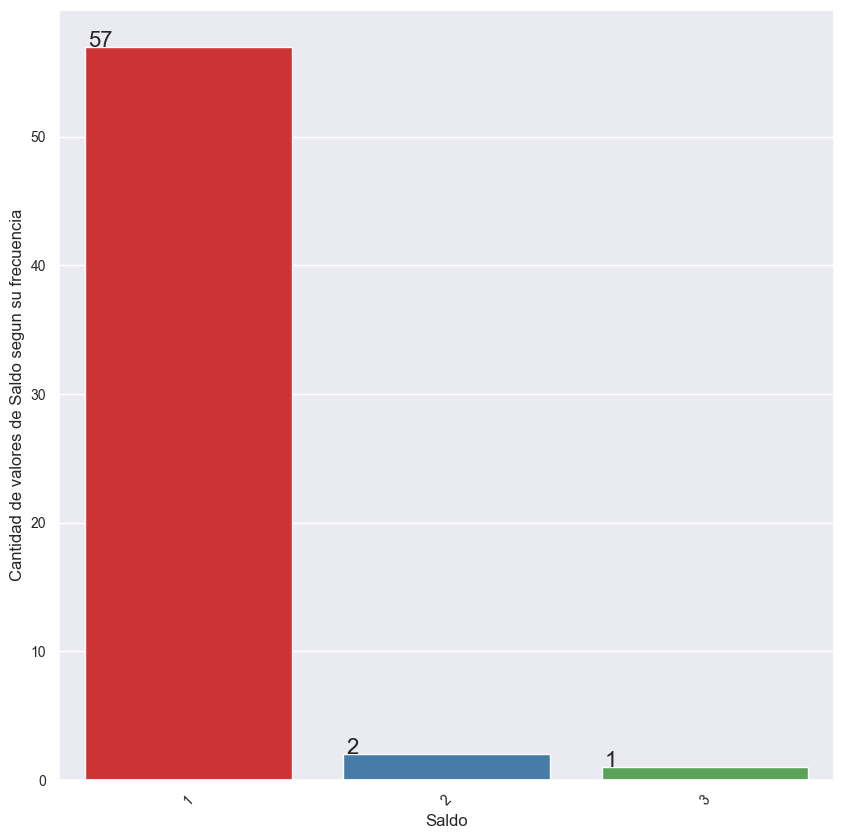

In [186]:
#se visualiza la cantidad de valores de Saldo segun su frecuencia
plt.figure(figsize=(10,10))
a = sns.countplot(x=Saldo_contacto['Saldo'].astype(str), hue=Saldo_contacto['Saldo'].astype(str), order=Saldo_contacto['Saldo'].value_counts().index.astype(str), palette="Set1", legend=False)
a.tick_params(labelsize=10)
for p in a.patches:
    a.annotate('{:.0f}'.format(p.get_height()), (p.get_x()+0.01, p.get_height()+0.01), fontsize=16)
plt.xticks(rotation=45)
plt.ylabel("Cantidad de valores de Saldo segun su frecuencia")
plt.show()

Saldo es variable sensible por poseer casos unicos


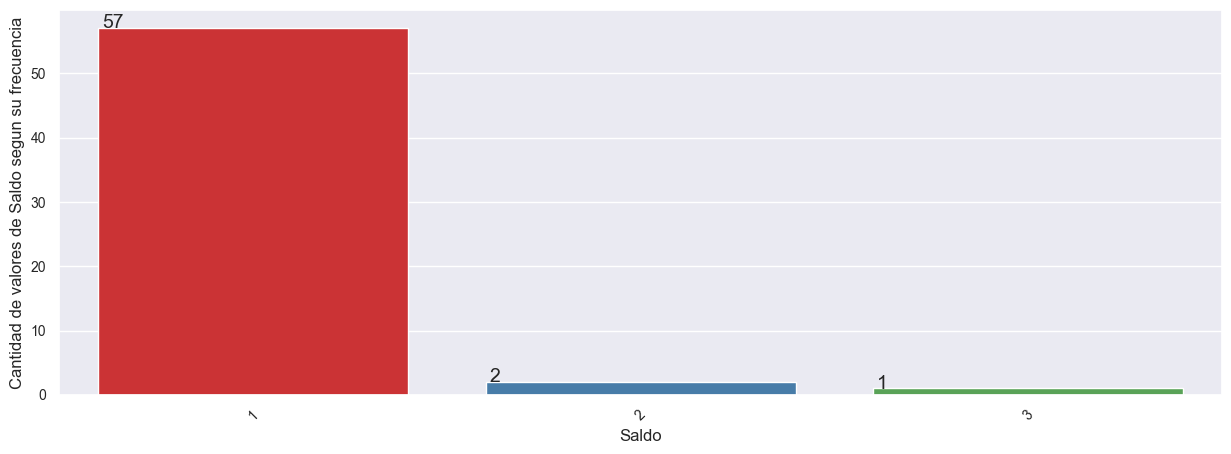

Saldo vencido es variable sensible por poseer casos unicos


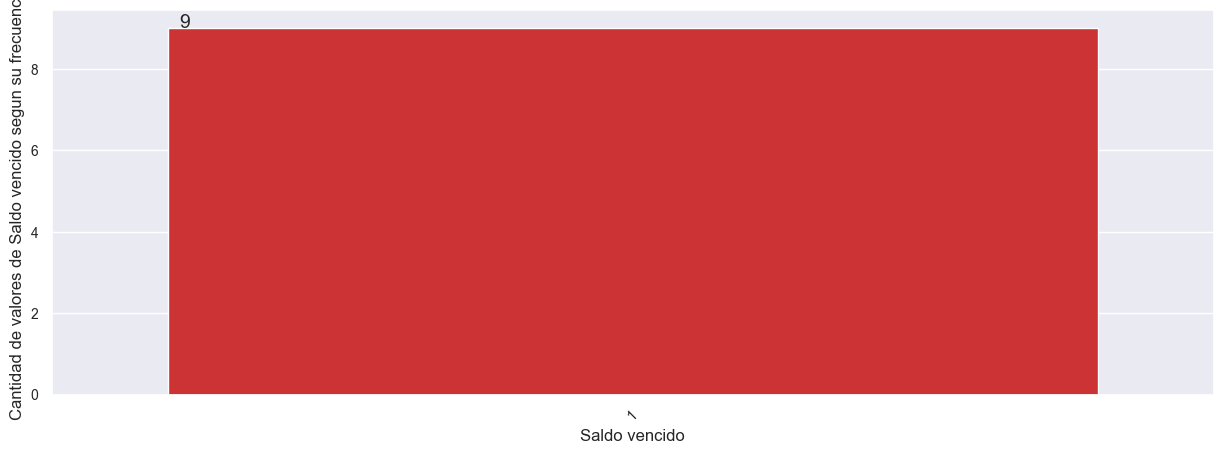

Creditos activos es variable sensible por poseer casos unicos


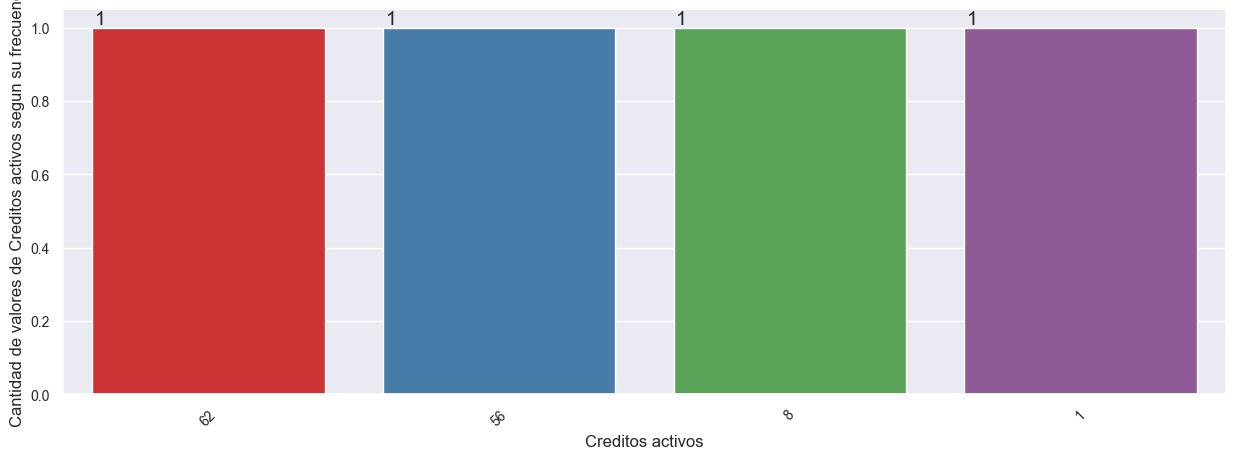

In [187]:
#Automatizando el conteo y obtencion de graficos - Contacto
columnas_contacto = ['State', 'Saldo', 'Saldo vencido', 'Creditos activos', 'Estado']

for i in columnas_contacto:
    casos = pd.DataFrame(contacto[i].groupby(contacto[i]).agg('count'))
    for j in casos:
        if casos[casos[j]==1].count().iloc[0] > 0:
            print(str(j)+' es variable sensible por poseer casos unicos')
            plt.figure(figsize=(15,5))
            a = sns.countplot(x=casos[j].astype(str), hue=casos[j].astype(str), order=casos[j].value_counts().index.astype(str), palette="Set1", legend=False)
            a.tick_params(labelsize=10)
            for p in a.patches:
                a.annotate('{:.0f}'.format(p.get_height()), (p.get_x()+0.01, p.get_height()+0.01), fontsize=14)
            plt.xticks(rotation=45)
            plt.ylabel('Cantidad de valores de '+str(i)+' segun su frecuencia')
            plt.show()

In [188]:
#se cuentan la cantidad de casos por Usuario
credito.groupby(['Usuario']).Usuario.agg('count')

Usuario
Administrator             80
Ignacio Rodríguez         53
María Micaela Tronelli    43
Toufic                    13
Name: Usuario, dtype: int64

Analizada individualmente, no posee casos únicos (sin riesgo).

In [189]:
#se cuentan la cantidad de casos por Monto
credito.groupby(['Monto']).Monto.agg('count')

Monto
20000.0        1
30000.0        1
40000.0        1
200000.0       1
300000.0       2
              ..
21000000.0     2
24203000.0     1
37000000.0     1
70000000.0     1
150000000.0    1
Name: Monto, Length: 72, dtype: int64

Como se observan casos donde existe un único valor, es variable sensible. Se cuentan para ver cuántos casos son riesgosos.

In [190]:
Monto_credito = pd.DataFrame(credito.groupby(['Monto']).Monto.agg('count'))
Monto_credito[Monto_credito['Monto']==1].count()

Monto    42
dtype: int64

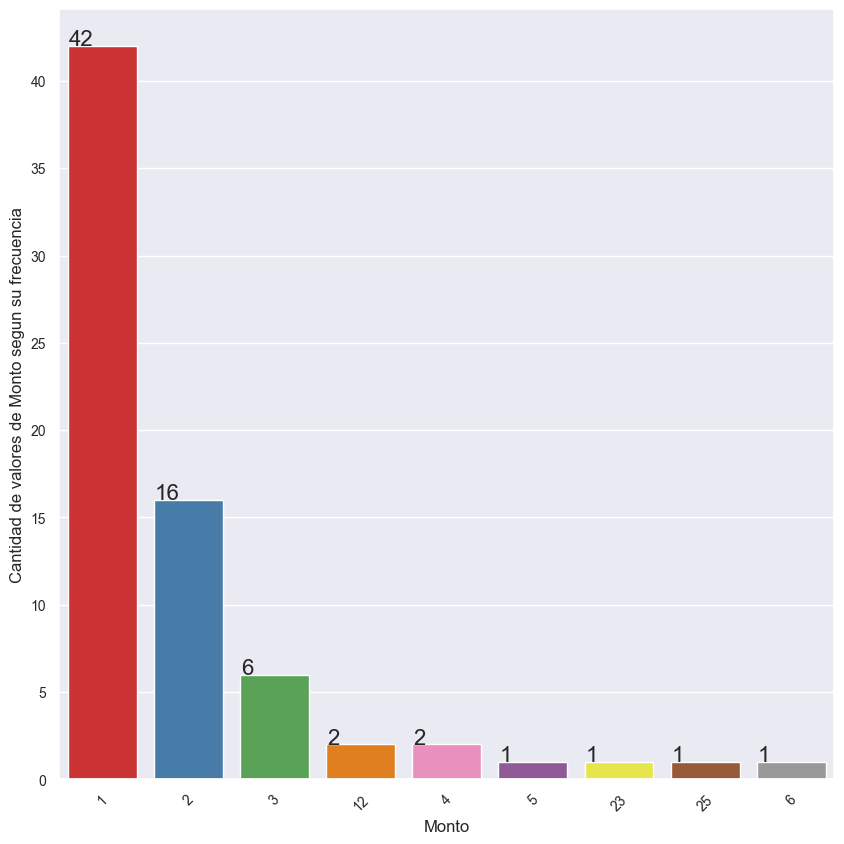

In [191]:
plt.figure(figsize=(10,10))
a = sns.countplot(x=Monto_credito['Monto'].astype(str), hue=Monto_credito['Monto'].astype(str), order=Monto_credito['Monto'].value_counts().index.astype(str), palette="Set1", legend=False)
a.tick_params(labelsize=10)
for p in a.patches:
    a.annotate('{:.0f}'.format(p.get_height()), (p.get_x()+0.01, p.get_height()+0.01), fontsize=16)
plt.xticks(rotation=45)
plt.ylabel("Cantidad de valores de Monto segun su frecuencia")
plt.show()

Monto es variable sensible por poseer casos unicos


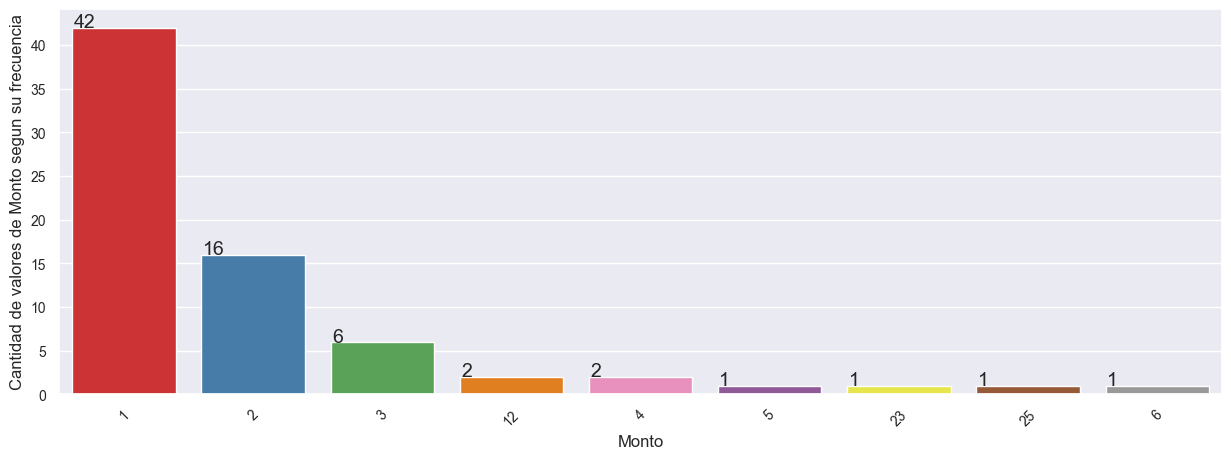

Plantilla es variable sensible por poseer casos unicos


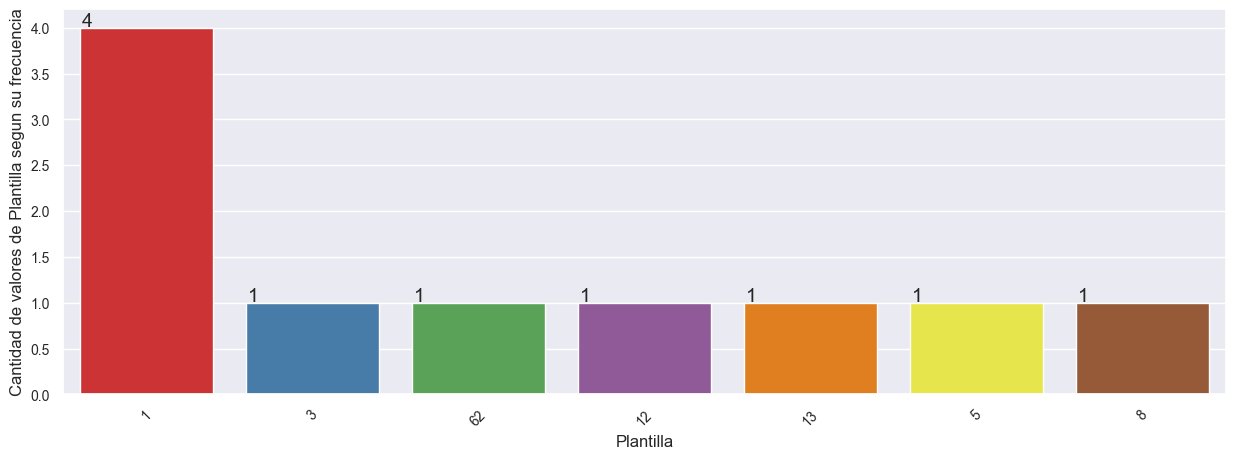

Cuotas activas es variable sensible por poseer casos unicos


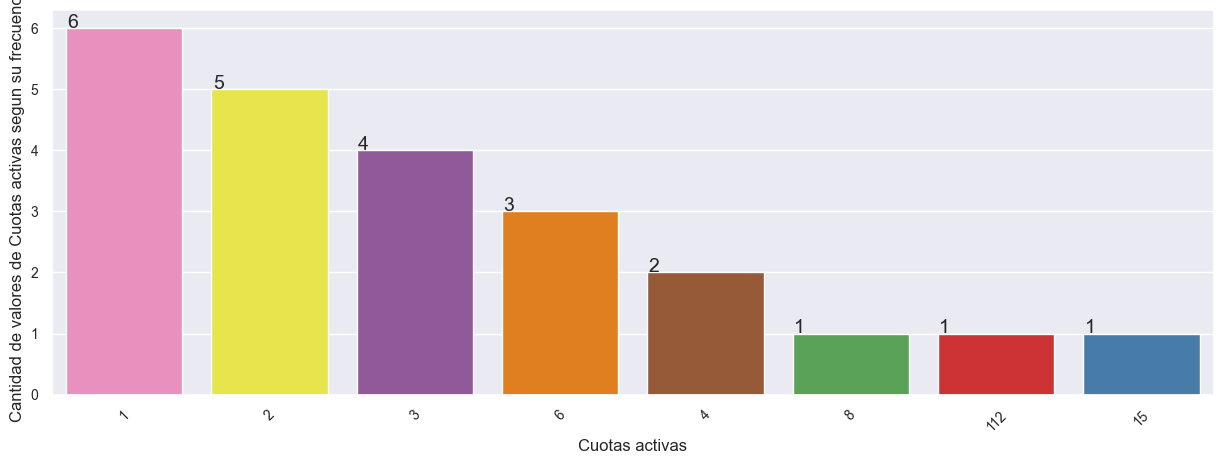

Saldo es variable sensible por poseer casos unicos


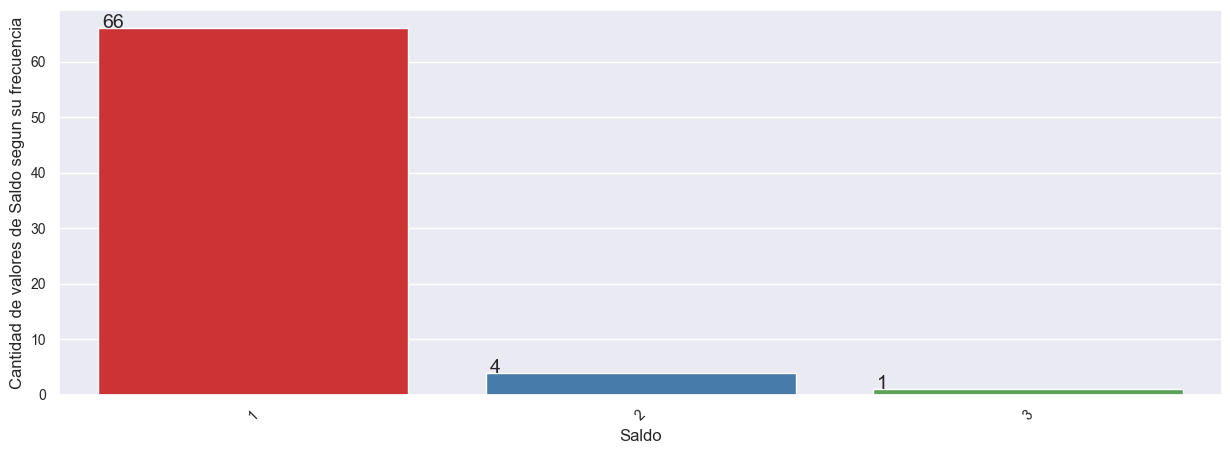

Estado es variable sensible por poseer casos unicos


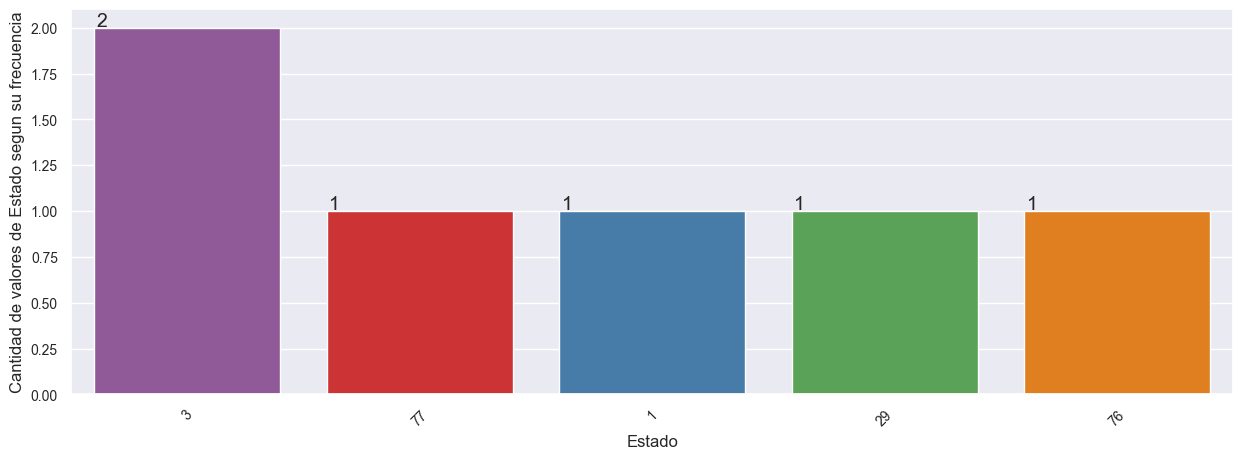

In [192]:
#Automatizando el conteo y obtencion de graficos - Credito
columnas_credito = ['Categoría de crédito', 'Linea de crédito', 'Usuario', 'Monto', 'Plantilla', 'Cuotas activas', 'Saldo', 'Estado']

for i in columnas_credito:
    casos = pd.DataFrame(credito[i].groupby(credito[i]).agg('count'))
    for j in casos:
        if casos[casos[j]==1].count().iloc[0] > 0:
            print(str(j)+' es variable sensible por poseer casos unicos')
            plt.figure(figsize=(15,5))
            a = sns.countplot(x=casos[j].astype(str), hue=casos[j].astype(str), order=casos[j].value_counts().index.astype(str), palette="Set1", legend=False)
            a.tick_params(labelsize=10)
            for p in a.patches:
                a.annotate('{:.0f}'.format(p.get_height()), (p.get_x()+0.01, p.get_height()+0.01), fontsize=14)
            plt.xticks(rotation=45)
            plt.ylabel('Cantidad de valores de '+str(i)+' segun su frecuencia')
            plt.show()

### 4.2 Identificación combinada

In [193]:
contacto_riesgo = contacto.copy()
contacto_riesgo["State"] = contacto_riesgo["State"].fillna("Sin dato")

credito_riesgo = credito.copy()
credito_riesgo["Linea de crédito"] = credito_riesgo["Linea de crédito"].fillna("Sin dato")

In [194]:
contacto_riesgo.groupby(['State', 'Estado']).agg('count')

Creado el  Saldo  \
State                                Estado                       
Ciudad Autónoma de Buenos Aires (AR) Aprobado          5      0   
                                     Borrador          1      0   
Neuquén (AR)                         Aprobado         10      8   
                                     Borrador          1      0   
                                     Revisión          1      1   
Río Negro (AR)                       Aprobado          6      5   
Sin dato                             Aprobado         66     44   
                                     Borrador         29      0   
                                     Revisión          8      6   

                                               Saldo vencido  \
State                                Estado                    
Ciudad Autónoma de Buenos Aires (AR) Aprobado              0   
                                     Borrador              0   
Neuquén (AR)                         Aprobado              2   
                                     Borrador              0   
                                     Revisión              0   
Río Negro (AR)                       Aprobado              1   
Sin dato                             Aprobado              5   
                                     Borrador              0   
                                     Revisión              1   

                                               Creditos activos  Cliente_id  \
State                                Estado                                   
Ciudad Autónoma de Buenos Aires (AR) Aprobado                 5           5   
                                     Borrador                 1           1   
Neuquén (AR)                         Aprobado                10          10   
                                     Borrador                 1           1   
                                     Revisión                 1           1   
Río Negro (AR)                       Aprobado                 6           6   
Sin dato                             Aprobado                66          66   
                                     Borrador                29          29   
                                     Revisión                 8           8   

                                               Identificacion_id  Mobile_id  \
State                                Estado                                   
Ciudad Autónoma de Buenos Aires (AR) Aprobado                  5          5   
                                     Borrador                  1          1   
Neuquén (AR)                         Aprobado                 10         10   
                                     Borrador                  1          1   
                                     Revisión                  1          1   
Río Negro (AR)                       Aprobado                  6          6   
Sin dato                             Aprobado                 66         66   
                                     Borrador                 29         29   
                                     Revisión                  8          8   

                                               Email_id  
State                                Estado              
Ciudad Autónoma de Buenos Aires (AR) Aprobado         5  
                                     Borrador         1  
Neuquén (AR)                         Aprobado        10  
                                     Borrador         1  
                                     Revisión         1  
Río Negro (AR)                       Aprobado         6  
Sin dato                             Aprobado        66  
                                     Borrador        29  
                                     Revisión         8

In [195]:
combinado_contacto = contacto_riesgo.groupby(['State', 'Estado'], as_index=False).size()
combinado_contacto

,State,Estado,size
0,Ciudad Autónoma de Buenos Aires (AR),Aprobado,5
1,Ciudad Autónoma de Buenos Aires (AR),Borrador,1
2,Neuquén (AR),Aprobado,10
3,Neuquén (AR),Borrador,1
4,Neuquén (AR),Revisión,1
5,Río Negro (AR),Aprobado,6
6,Sin dato,Aprobado,66
7,Sin dato,Borrador,29
8,Sin dato,Revisión,8


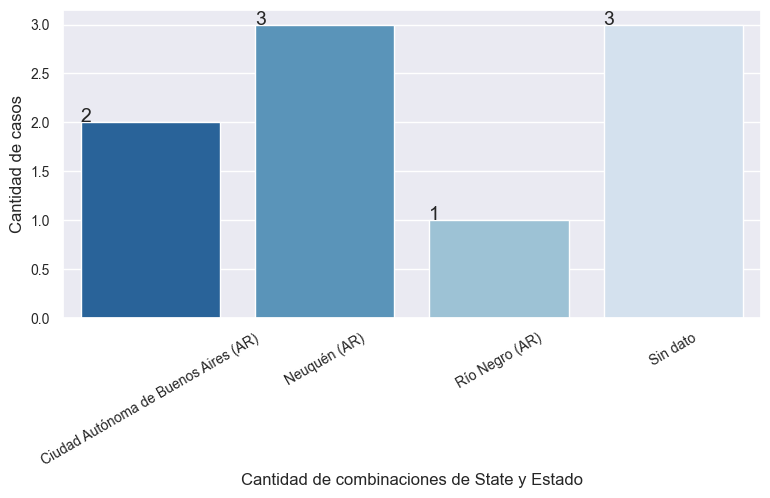

In [196]:
plt.figure(figsize=(9, 4))
a = sns.countplot(x=combinado_contacto['State'].astype(str), hue=combinado_contacto['State'].astype(str), palette='Blues_r', legend=False)
a.tick_params(labelsize=10)
for p in a.patches:
    a.annotate('{:.0f}'.format(p.get_height()), (p.get_x(), p.get_height()), fontsize=14)
plt.xticks(rotation=30)
plt.xlabel('Cantidad de combinaciones de State y Estado')
plt.ylabel('Cantidad de casos')
plt.show()

In [197]:
_g = contacto_riesgo.groupby(['State', 'Estado']).size().reset_index(name='casos')
_afectados = _g.loc[_g['casos'] == 1, 'casos'].sum()
'el {:.2f}% de individuos son posibles de identificar a partir de combinar las variables State y Estado'.format(_afectados/len(contacto_riesgo)*100)

'el 2.36% de individuos son posibles de identificar a partir de combinar las variables State y Estado'

Se agrega una tercera variable, Creditos activos, para evaluar si el riesgo aumenta.

In [198]:
contacto_riesgo.groupby(['State', 'Estado', 'Creditos activos']).agg('count')

Creado el  \
State                                Estado   Creditos activos              
Ciudad Autónoma de Buenos Aires (AR) Aprobado 0                         5   
                                     Borrador 0                         1   
Neuquén (AR)                         Aprobado 0                         1   
                                              1                         8   
                                              6                         1   
                                     Borrador 0                         1   
                                     Revisión 2                         1   
Río Negro (AR)                       Aprobado 0                         1   
                                              1                         5   
Sin dato                             Aprobado 0                        22   
                                              1                        37   
                                              2                         7   
                                     Borrador 0                        29   
                                     Revisión 0                         2   
                                              1                         6   

                                                                Saldo  \
State                                Estado   Creditos activos          
Ciudad Autónoma de Buenos Aires (AR) Aprobado 0                     0   
                                     Borrador 0                     0   
Neuquén (AR)                         Aprobado 0                     0   
                                              1                     7   
                                              6                     1   
                                     Borrador 0                     0   
                                     Revisión 2                     1   
Río Negro (AR)                       Aprobado 0                     0   
                                              1                     5   
Sin dato                             Aprobado 0                     0   
                                              1                    37   
                                              2                     7   
                                     Borrador 0                     0   
                                     Revisión 0                     0   
                                              1                     6   

                                                                Saldo vencido  \
State                                Estado   Creditos activos                  
Ciudad Autónoma de Buenos Aires (AR) Aprobado 0                             0   
                                     Borrador 0                             0   
Neuquén (AR)                         Aprobado 0                             0   
                                              1                             2   
                                              6                             0   
                                     Borrador 0                             0   
                                     Revisión 2                             0   
Río Negro (AR)                       Aprobado 0                             0   
                                              1                             1   
Sin dato                             Aprobado 0                             0   
                                              1                             3   
                                              2                             2   
                                     Borrador 0                             0   
                                     Revisión 0                             0   
                                              1                             1   

                                                                Cliente_id  \
State                                Estado   Creditos a

In [199]:
combinado_contacto_3 = contacto_riesgo.groupby(['State', 'Estado', 'Creditos activos'], as_index=False).size()
combinado_contacto_3

,State,Estado,Creditos activos,size
0,Ciudad Autónoma de Buenos Aires (AR),Aprobado,0,5
1,Ciudad Autónoma de Buenos Aires (AR),Borrador,0,1
2,Neuquén (AR),Aprobado,0,1
3,Neuquén (AR),Aprobado,1,8
4,Neuquén (AR),Aprobado,6,1
5,Neuquén (AR),Borrador,0,1
6,Neuquén (AR),Revisión,2,1
7,Río Negro (AR),Aprobado,0,1
8,Río Negro (AR),Aprobado,1,5
9,Sin dato,Aprobado,0,22


In [200]:
_g3 = contacto_riesgo.groupby(['State', 'Estado', 'Creditos activos']).size().reset_index(name='casos')
_afectados_3 = _g3.loc[_g3['casos'] == 1, 'casos'].sum()
'El {:.2f}% de individuos son posibles de identificar a partir de combinar las variables State, Estado y Creditos activos'.format(_afectados_3/len(contacto_riesgo)*100)

'El 4.72% de individuos son posibles de identificar a partir de combinar las variables State, Estado y Creditos activos'

Agregar una tercera variable sube el porcentaje de identificación unívoca.

In [201]:
credito_riesgo.groupby(['Linea de crédito', 'Estado']).agg('count')

Fecha  Nombre  \
Linea de crédito               Estado                         
Credito Empleado Liess         Acreditado         1       1   
                               Pagado             1       1   
                               Rechazado          1       1   
Crédito con garantía prendaria Acreditado         2       2   
                               Rechazado          4       4   
Crédito personal               Acreditado        68      68   
                               Borrador           1       1   
                               Pagado             6       6   
                               Pre-cancelado      3       3   
                               Rechazado         21      21   
                               Refinanciado       3       3   
Descuento de cheques           Acreditado         6       6   
                               Pagado            22      22   
                               Rechazado          5       5   
Sin dato                       Rechazado         45      45   

                                              Categoría de crédito  Usuario  \
Linea de crédito               Estado                                         
Credito Empleado Liess         Acreditado                        1        1   
                               Pagado                            1        1   
                               Rechazado                         1        1   
Crédito con garantía prendaria Acreditado                        2        2   
                               Rechazado                         4        4   
Crédito personal               Acreditado                       68       68   
                               Borrador                          1        1   
                               Pagado                            6        6   
                               Pre-cancelado                     3        3   
                               Rechazado                        21       21   
                               Refinanciado                      3        3   
Descuento de cheques           Acreditado                        6        6   
                               Pagado                           22       22   
                               Rechazado                         5        5   
Sin dato                       Rechazado                        45       45   

                                              Monto  Plantilla  \
Linea de crédito               Estado                            
Credito Empleado Liess         Acreditado         1          1   
                               Pagado             1          1   
                               Rechazado          1          1   
Crédito con garantía prendaria Acreditado         2          2   
                               Rechazado          4          4   
Crédito personal               Acreditado        68         68   
                               Borrador           1          1   
                               Pagado             6          6   
                               Pre-cancelado      3          3   
                               Rechazado         21         17   
                               Refinanciado       3          3   
Descuento de cheques           Acreditado         6          0   
                               Pagado            22          0   
                               Rechazado          5          0   
Sin dato                       Rechazado         39          0   

                                              Cuotas activas  Saldo  otorgado  \
Linea de crédito               Estado                                           
Credito Empleado Liess         Acreditado                  1      1         1   
                               Pagado                      1      0         1   
                               Rechazado                   1      0         1   
Crédito con garantía prendaria Acreditado                  2      2         2   
                     

In [202]:
combinado_credito = credito_riesgo.groupby(['Linea de crédito', 'Estado'], as_index=False).size()
combinado_credito

,Linea de crédito,Estado,size
0,Credito Empleado Liess,Acreditado,1
1,Credito Empleado Liess,Pagado,1
2,Credito Empleado Liess,Rechazado,1
3,Crédito con garantía prendaria,Acreditado,2
4,Crédito con garantía prendaria,Rechazado,4
5,Crédito personal,Acreditado,68
6,Crédito personal,Borrador,1
7,Crédito personal,Pagado,6
8,Crédito personal,Pre-cancelado,3
9,Crédito personal,Rechazado,21


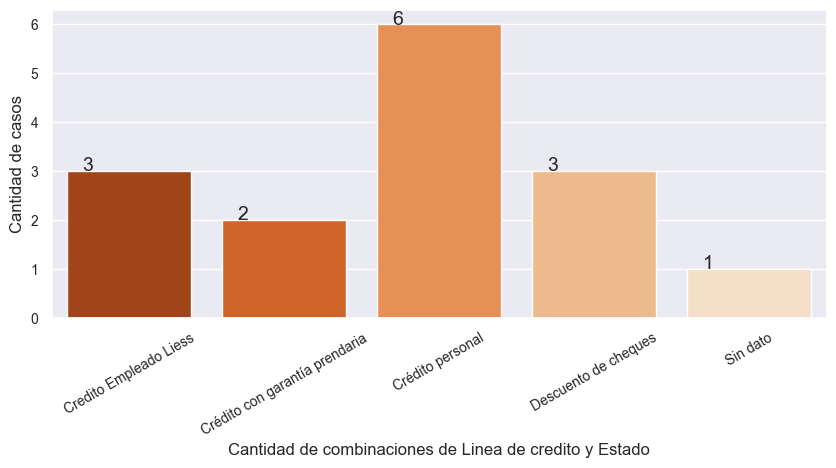

In [203]:
plt.figure(figsize=(10, 4))
a = sns.countplot(x=combinado_credito['Linea de crédito'].astype(str), hue=combinado_credito['Linea de crédito'].astype(str), palette='Oranges_r', legend=False)
a.tick_params(labelsize=10)
for p in a.patches:
    a.annotate('{:.0f}'.format(p.get_height()), (p.get_x()+0.1, p.get_height()), fontsize=14)
plt.xticks(rotation=30)
plt.xlabel('Cantidad de combinaciones de Linea de credito y Estado')
plt.ylabel('Cantidad de casos')
plt.show()

Linea de credito se excluyo de los promedios y tasas por linea del EDA, pero aca se mantiene su nulo (como Sin dato) porque sin linea asignada es en si misma una combinacion posible de identificar, distinta de tratarla como una categoria de producto.

In [204]:
_gc = credito_riesgo.groupby(['Linea de crédito', 'Estado']).size().reset_index(name='casos')
_afectados_c = _gc.loc[_gc['casos'] == 1, 'casos'].sum()
'el {:.2f}% de individuos son posibles de identificar a partir de combinar las variables Linea de credito y Estado'.format(_afectados_c/len(credito_riesgo)*100)

'el 2.12% de individuos son posibles de identificar a partir de combinar las variables Linea de credito y Estado'

Se agrega Usuario como tercera variable, para evaluar si conocer ademas quien gestiono la solicitud incrementa el riesgo.

In [205]:
credito_riesgo.groupby(['Linea de crédito', 'Estado', 'Usuario']).agg('count')

Fecha  \
Linea de crédito               Estado        Usuario                         
Credito Empleado Liess         Acreditado    Ignacio Rodríguez           1   
                               Pagado        Administrator               1   
                               Rechazado     Administrator               1   
Crédito con garantía prendaria Acreditado    Ignacio Rodríguez           1   
                                             María Micaela Tronelli      1   
                               Rechazado     Administrator               2   
                                             María Micaela Tronelli      2   
Crédito personal               Acreditado    Administrator              26   
                                             Ignacio Rodríguez          18   
                                             María Micaela Tronelli     24   
                               Borrador      María Micaela Tronelli      1   
                               Pagado        Administrator               2   
                                             María Micaela Tronelli      3   
                                             Toufic                      1   
                               Pre-cancelado María Micaela Tronelli      3   
                               Rechazado     Administrator              13   
                                             Ignacio Rodríguez           4   
                                             María Micaela Tronelli      3   
                                             Toufic                      1   
                               Refinanciado  María Micaela Tronelli      3   
Descuento de cheques           Acreditado    Ignacio Rodríguez           5   
                                             Toufic                      1   
                               Pagado        Ignacio Rodríguez          13   
                                             María Micaela Tronelli      2   
                                             Toufic                      7   
                               Rechazado     Ignacio Rodríguez           4   
                                             María Micaela Tronelli      1   
Sin dato                       Rechazado     Administrator              35   
                                             Ignacio Rodríguez           7   
                                             Toufic                      3   

                                                                     Nombre  \
Linea de crédito               Estado        Usuario                          
Credito Empleado Liess         Acreditado    Ignacio Rodríguez            1   
                               Pagado        Administrator                1   
                               Rechazado     Administrator                1   
Crédito con garantía prendaria Acreditado    Ignacio Rodríguez            1   
                                             María Micaela Tronelli       1   
                               Rechazado     Administrator                2   
                                             María Micaela Tronelli       2   
Crédito personal               Acreditado    Administrator               26   
                                             Ignacio Rodríguez           18   
                                             María Micaela Tronelli      24   
                               Borrador      María Micaela Tronelli       1   
                               Pagado        Administrator                2   
                                             María Micaela Tronelli       3   
                                             Toufic                       1   
                               Pre-cancelado María Micaela Tronelli       3   
                               Rechazado     Administrator               13   
                                             Ignacio Rodríguez            4   
                                             María Micaela Tronelli    

In [206]:
combinado_credito_3 = credito_riesgo.groupby(['Linea de crédito', 'Estado', 'Usuario'], as_index=False).size()
combinado_credito_3

,Linea de crédito,Estado,Usuario,size
0,Credito Empleado Liess,Acreditado,Ignacio Rodríguez,1
1,Credito Empleado Liess,Pagado,Administrator,1
2,Credito Empleado Liess,Rechazado,Administrator,1
3,Crédito con garantía prendaria,Acreditado,Ignacio Rodríguez,1
4,Crédito con garantía prendaria,Acreditado,María Micaela Tronelli,1
5,Crédito con garantía prendaria,Rechazado,Administrator,2
6,Crédito con garantía prendaria,Rechazado,María Micaela Tronelli,2
7,Crédito personal,Acreditado,Administrator,26
8,Crédito personal,Acreditado,Ignacio Rodríguez,18
9,Crédito personal,Acreditado,María Micaela Tronelli,24


In [207]:
_gc3 = credito_riesgo.groupby(['Linea de crédito', 'Estado', 'Usuario']).size().reset_index(name='casos')
_afectados_c3 = _gc3.loc[_gc3['casos'] == 1, 'casos'].sum()
'El {:.2f}% de individuos son posibles de identificar a partir de combinar las variables Linea de credito, Estado y Usuario'.format(_afectados_c3/len(credito_riesgo)*100)

'El 5.29% de individuos son posibles de identificar a partir de combinar las variables Linea de credito, Estado y Usuario'

Igual que en Contacto, sumar Usuario como tercera variable aumenta el porcentaje de identificación unívoca.

### 4.3 Aplicación de Privacidad Diferencial

In [208]:
credito_pd = credito.dropna(subset=['Monto']).copy().reset_index(drop=True)

In [209]:
credito_pd['Monto'].min()

20000.0

In [210]:
credito_pd['Monto'].max()

150000000.0

In [211]:
credito_pd.groupby(['Monto']).Monto.agg('count')

Monto
20000.0        1
30000.0        1
40000.0        1
200000.0       1
300000.0       2
              ..
21000000.0     2
24203000.0     1
37000000.0     1
70000000.0     1
150000000.0    1
Name: Monto, Length: 72, dtype: int64

In [212]:
credito_pd['Monto'].quantile([.25, .5, .75])

0.25    2000000.0
0.50    3000000.0
0.75    7290062.5
Name: Monto, dtype: float64

In [213]:
categorias_monto = ['<= 2.25M', '2.25M-3.25M', '3.25M-7.25M', '> 7.25M']
cut_bins = [-1, 2_250_000, 3_250_000, 7_251_234, credito_pd['Monto'].max() + 1]
credito_pd['Monto_cat'] = pd.cut(credito_pd['Monto'], bins=cut_bins, labels=categorias_monto)

Se categoriza Monto en cuatro rangos, definidos a partir de los cuartiles de su distribución (corridos levemente para no coincidir con montos redondos muy frecuentes), para poder visualizar y aplicar el mecanismo de histograma de Privacidad Diferencial.

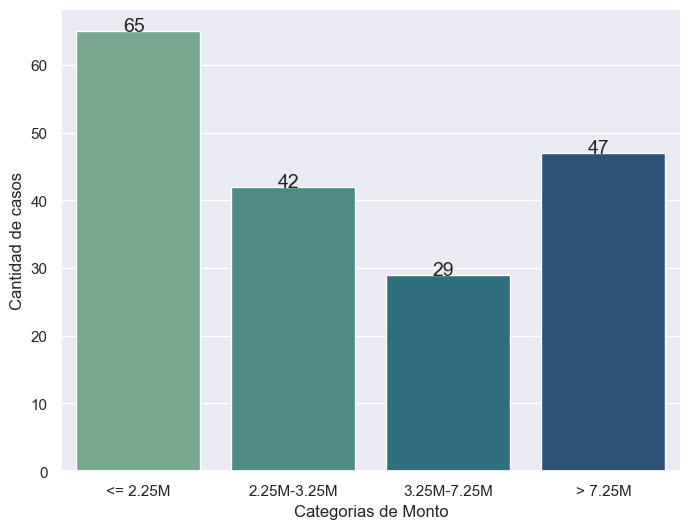

In [214]:
plt.figure(figsize=(8, 6))
m = sns.countplot(x='Monto_cat', data=credito_pd, order=categorias_monto, palette='crest')
for p in m.patches:
    m.annotate('{:.0f}'.format(p.get_height()), (p.get_x()+0.3, p.get_height()), fontsize=14)
plt.ylabel('Cantidad de casos')
plt.xlabel('Categorias de Monto')
plt.show()

In [215]:
sample_size = 50
sample = credito_pd.sample(n=sample_size, random_state=np.random.seed(2024))
sample.to_csv('samplefile.csv', index=False, header=False)

In [216]:
sample.shape

(50, 13)

In [217]:
sample.columns

Index(['Fecha', 'Nombre', 'Categoría de crédito', 'Linea de crédito',
       'Usuario', 'Monto', 'Plantilla', 'Cuotas activas', 'Saldo', 'Estado',
       'otorgado', 'Cliente_id', 'Monto_cat'],
      dtype='object')

In [218]:

!pip install -q --break-system-packages opendp

In [219]:
col_names = ['Monto', 'Monto_cat']
categories = ['<= 2.25M', '2.25M-3.25M', '3.25M-7.25M', '> 7.25M']
import opendp.prelude as dp
dp.enable_features('contrib', 'floating-point')
max_influence = 1
budget = (0.8, 1e-8)

muestra_pd = sample[col_names].copy()
muestra_pd.to_csv('samplefile.csv', index=False, header=False)

with open('samplefile.csv') as input_data:
    datos_csv = input_data.read()

histograma = (
    dp.t.make_split_dataframe(separator=',', col_names=col_names) >>
    dp.t.make_select_column(key='Monto_cat', TOA=str) >>
    dp.t.then_count_by_categories(categories=categories)
)

noisy_histogram = dp.binary_search_chain(lambda s: histograma >> dp.m.then_laplace(scale=s), d_in=max_influence, d_out=budget[0])

sensitive_counts = histograma(datos_csv)
np.random.seed(2024)
released_counts = noisy_histogram(datos_csv)

print('Conteos reales:', sensitive_counts)
print('Conteos publicados:', released_counts)

Conteos reales: [16, 14, 8, 12, 0]
Conteos publicados: [16, 13, 9, 12, -1]


Se crea una funcion para aplicar Privacidad Diferencial para diferentes tamaños de muestra y valores de epsilon.

In [220]:
def evaluacion(datos, sample_sizes, epsilons, categories, name_key):
    col_names = ['Monto', 'Monto_cat']
    for sample_size in sample_sizes:
        sample = datos[col_names].sample(n=sample_size, random_state=np.random.seed(2024))
        sample.to_csv('samplefile.csv', index=False, header=False)

        with open('samplefile.csv') as input_data:
            datos_csv = input_data.read()

        histograma = (
            dp.t.make_split_dataframe(separator=',', col_names=col_names) >>
            dp.t.make_select_column(key=name_key, TOA=str) >>
            dp.t.then_count_by_categories(categories=categories)
        )
        sensitive_counts = histograma(datos_csv)

        for epsilon in epsilons:
            noisy_histogram = dp.binary_search_chain(lambda s: histograma >> dp.m.then_laplace(scale=s), d_in=max_influence, d_out=epsilon)
            np.random.seed(2024)
            released_counts = noisy_histogram(datos_csv)
            error = np.mean(np.abs(np.array(sensitive_counts[:-1]) - np.array(released_counts[:-1])) / sample_size) * 100
            print(f'n={sample_size}, epsilon={epsilon}: error medio = {error:.2f}%')

In [221]:
evaluacion(credito_pd, [50, 100, 150, 180], [0.8, 0.5, 0.25, 0.05], ['<= 2.25M', '2.25M-3.25M', '3.25M-7.25M', '> 7.25M'], 'Monto_cat')

n=50, epsilon=0.8: error medio = 4.00%
n=50, epsilon=0.5: error medio = 1.50%
n=50, epsilon=0.25: error medio = 7.00%
n=50, epsilon=0.05: error medio = 39.50%
n=100, epsilon=0.8: error medio = 1.75%
n=100, epsilon=0.5: error medio = 5.75%
n=100, epsilon=0.25: error medio = 3.50%
n=100, epsilon=0.05: error medio = 13.75%
n=150, epsilon=0.8: error medio = 0.67%
n=150, epsilon=0.5: error medio = 1.00%
n=150, epsilon=0.25: error medio = 1.17%
n=150, epsilon=0.05: error medio = 13.17%
n=180, epsilon=0.8: error medio = 0.56%
n=180, epsilon=0.5: error medio = 0.83%
n=180, epsilon=0.25: error medio = 1.25%
n=180, epsilon=0.05: error medio = 11.25%


El patrón general se cumple: a menor epsilon, mayor error; a mayor tamaño de muestra, menor error y más estable. Sin embargo, en algunos tramos puntuales (sobre todo con muestras chicas) el orden se invierte entre epsilons cercanos: el mecanismo de Laplace agrega ruido aleatorio, por lo que una corrida individual puede apartarse de la tendencia promedio sin que eso invalide el patrón general.

### 4.4 Implementación final de ruido aleatorio y evaluación de resultados

In [222]:
def ruido(data, variable, variable_new, sensitivity, epsilon):
    np.random.seed(2024)
    data[variable_new] = data[variable] + np.random.laplace(loc=0, scale=sensitivity / epsilon, size=len(data))
    return data

In [223]:
credito_pd = ruido(credito_pd, 'Monto', 'Monto_ruido', 50_000, 0.25)
credito_pd['Monto_ruido_cat'] = pd.cut(credito_pd['Monto_ruido'], bins=cut_bins, labels=categorias_monto)

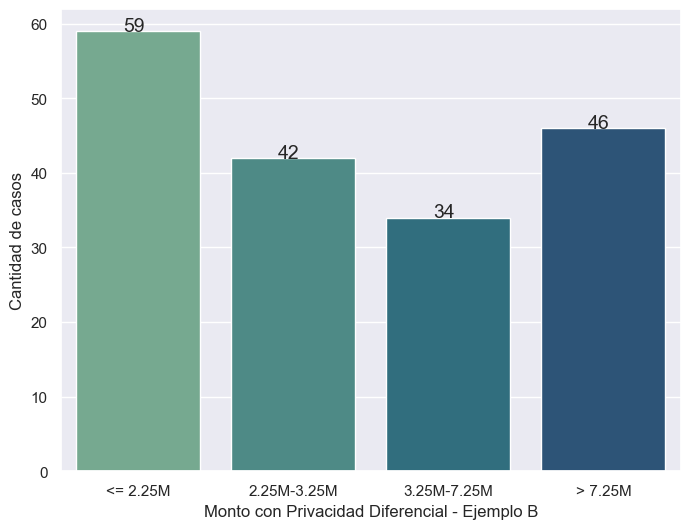

In [224]:
plt.figure(figsize=(8, 6))
dpB = sns.countplot(x='Monto_ruido_cat', data=credito_pd, order=categorias_monto, palette='crest')
for p in dpB.patches:
    dpB.annotate('{:.0f}'.format(p.get_height()), (p.get_x()+0.3, p.get_height()+0.01), fontsize=14)
plt.ylabel('Cantidad de casos')
plt.xlabel('Monto con Privacidad Diferencial - Ejemplo B')
plt.show()

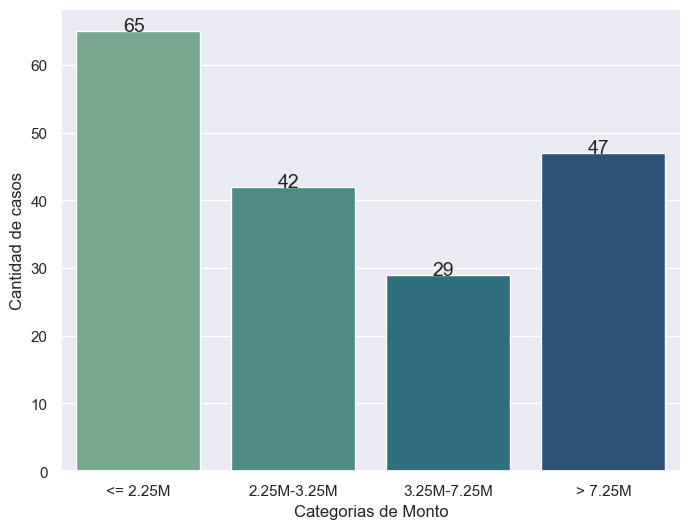

In [225]:
#ORIGINAL
plt.figure(figsize=(8, 6))
m = sns.countplot(x='Monto_cat', data=credito_pd, order=categorias_monto, palette='crest')
for p in m.patches:
    m.annotate('{:.0f}'.format(p.get_height()), (p.get_x()+0.3, p.get_height()), fontsize=14)
plt.ylabel('Cantidad de casos')
plt.xlabel('Categorias de Monto')
plt.show()

Los cortes de categoria se corren a 2.25M y 3.25M para no coincidir con montos redondos muy frecuentes (2M y 3M concentran muchos creditos), y se usa una escala de ruido chica, asi se conserva una distribucion parecida a la original.

#### Evaluación de resultados

In [226]:
import scipy.stats as stats
stats.levene(credito_pd['Monto'], credito_pd['Monto_ruido'], center='mean')

LeveneResult(statistic=np.float64(4.720116134282881e-05), pvalue=np.float64(0.9945220924441148))

El p-valor supera a alfa=0,05: no hay evidencia de que las varianzas difieran. El ruido no cambia significativamente la distribución de Monto. Por lo tanto, si solo se tuviese Monto_ruido y se tratara de encontrar el Monto real de un credito puntual a partir de ese valor, ya no es posible hacerlo con precision.

### 4.5 Impacto en un modelo predictivo

El target es la aprobación del crédito (Acreditado/Rechazado), las dos categorías principales. Se usa Random Forest.

In [227]:
modelo_df = credito_pd[credito_pd['Estado'].isin(['Acreditado', 'Rechazado'])].copy()
modelo_df['Aprobado'] = (modelo_df['Estado'] == 'Acreditado').astype(int)

usuario_dummies = pd.get_dummies(modelo_df['Usuario'], prefix='Usuario')
modelo_df['Aprobado'].value_counts()

Aprobado
1    77
0    70
Name: count, dtype: int64

In [228]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def evaluar_modelo(columna_monto):
    X = pd.concat([modelo_df[[columna_monto]].rename(columns={columna_monto: 'Monto'}), usuario_dummies], axis=1)
    y = modelo_df['Aprobado']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=rand_state, stratify=y)
    modelo = RandomForestClassifier(random_state=rand_state)
    modelo.fit(X_train, y_train)
    prediccion = modelo.predict(X_test)
    return accuracy_score(y_test, prediccion)

accuracy_sin_ruido = evaluar_modelo('Monto')
accuracy_con_ruido = evaluar_modelo('Monto_ruido')

print(f'Accuracy sin ruido: {accuracy_sin_ruido:.4f}')
print(f'Accuracy con ruido: {accuracy_con_ruido:.4f}')

Accuracy sin ruido: 0.5667
Accuracy con ruido: 0.5333


El accuracy es similar con y sin ruido, consistente con que Levene no detectó cambio de varianza en Monto: con una escala de ruido tan chica, el modelo no se ve afectado.

El análisis muestra que, aun anonimizando identificadores directos, combinar identificadores indirectos(localidad y estado del contacto, o línea de crédito y estado del crédito) permite reidentificar a un porcentaje acotado pero no nulo de registros, que crece al sumar una tercera variable. Se aplicó Privacidad Diferencial sobre Monto, sin modificar significativamente su varianza ni la performance del modelo de Random Forest que la usa como predictora. De todos modos, el volumen de datos disponible es todavía demasiado chico para que un modelo predictivo como este sea viable en la práctica. La relevancia de este tipo de análisis crece a medida que la cartera aumente.

## 5. Exportación de datos para el tablero en Streamlit



In [257]:
import os
os.makedirs("dashboard_data", exist_ok=True)

# 1) KPIs de resumen (una sola fila, para las tarjetas de la pantalla principal)
kpis_resumen = pd.DataFrame([{
    "tasa_aprobacion_pct": tasa_aprobacion,
    "total_otorgado": credito_otorgado["Monto"].sum(),
    "monto_cuotas": monto_cuotas,  # capital + interés + cargo + impuesto de todo el cronograma
    "total_cobrado": monto_cobrado,
    "tasa_cobranza_pct": tasa_cobranza,  # Cobrado / Monto de cuotas 
    "monto_pendiente_cobro": monto_cuotas - monto_cobrado,  # misma base que monto_cuotas: monto_cuotas = total_cobrado + monto_pendiente_cobro
    "pct_en_mora": cuotas.groupby("Estado de mora")["Cuota - Saldo"].sum().pipe(
        lambda s: s[s.index != "Normal"].sum() / s.sum() * 100
    ),
}])
kpis_resumen.to_csv("dashboard_data/kpis_resumen.csv", index=False)

# 2) Tabla operativa por cliente (ya anonimizada)
tabla.to_csv("dashboard_data/tabla_clientes.csv", index=False)

# 3) Evolución mensual de crédito otorgado, por línea 
evolucion.reset_index().melt(id_vars="Mes", var_name="Linea de crédito", value_name="Monto") \
    .to_csv("dashboard_data/evolucion_credito.csv", index=False)

# 4) Concentración de cartera por línea
concentracion = pd.DataFrame({
    "Linea de crédito": concentracion_monto_pct.index,
    "monto": concentracion_monto.reindex(concentracion_monto_pct.index).values,
    "monto_pct": concentracion_monto_pct.values,
    "cantidad": concentracion_cantidad.reindex(concentracion_monto_pct.index).values,
    "cantidad_pct": concentracion_cantidad_pct.reindex(concentracion_monto_pct.index).values,
})
concentracion.to_csv("dashboard_data/concentracion_linea.csv", index=False)

# 5) Distribución de mora 
mora_dist = pd.DataFrame({
    "Estado de mora": dist_cantidad.index,
    "cantidad": dist_cantidad.values,
    "monto": cuotas.groupby("Estado de mora")["Cuota - Saldo"].sum().reindex(dist_cantidad.index).values,
})
mora_dist.to_csv("dashboard_data/mora_distribucion.csv", index=False)

# 6) Composición mensual de la cuota 
mensual.reset_index().rename(columns={"index": "Mes"}).to_csv("dashboard_data/composicion_cuota.csv", index=False)

# 7) Cobros confirmados vs. crédito otorgado, por mes
cobros_vs_credito = pd.DataFrame({
    "Mes": cobros_mensual.index,
    "Cobrado": cobros_mensual.values,
}).merge(
    pd.DataFrame({"Mes": credito_otorgado_mensual.index, "Credito_otorgado": credito_otorgado_mensual.values}),
    on="Mes", how="outer"
).sort_values("Mes")
cobros_vs_credito.to_csv("dashboard_data/cobros_vs_credito.csv", index=False)

# 8) Horizonte completo de vencimientos hasta 2029, por línea
evol_horizonte.reset_index().melt(id_vars="Mes", var_name="Linea de crédito", value_name="Monto") \
    .to_csv("dashboard_data/horizonte_2029.csv", index=False)

# 9) Créditos por estado, en valores crudos (cantidad y monto) para el gráfico "Créditos por estado"
estado_credito = pd.DataFrame({
    "Estado": credito_valido["Estado"].value_counts().index,
    "cantidad": credito_valido["Estado"].value_counts().values,
    "monto": credito_valido.groupby("Estado")["Monto"].sum().reindex(credito_valido["Estado"].value_counts().index).values,
})
estado_credito.to_csv("dashboard_data/estado_credito.csv", index=False)

# 10) Cronograma de cuotas SIN recortar (para la proyección hacia el futuro en el gráfico de cobros)
proyeccion_cuotas = cuotas_tiempo.groupby("Mes")["Cuota - Monto"].sum().reset_index()
proyeccion_cuotas.columns = ["Mes", "Monto_programado"]
proyeccion_cuotas.to_csv("dashboard_data/proyeccion_cuotas.csv", index=False)

# 11) Detalle de creditos (para recalcular KPIs, concentracion y estado, filtrando por fecha en el tablero)
credito_detalle = credito_valido[["Fecha", "Linea de crédito", "Estado", "Monto"]].copy()
credito_detalle.to_csv("dashboard_data/credito_detalle.csv", index=False)

# 12) Detalle de cuotas (para recalcular monto de cuotas y mora, filtrando por fecha de vencimiento)
cuotas_detalle = cuotas[
    [
        "Fecha de vencimiento",
        "Estado de mora",
        "Cuota - Monto",
        "Cuota - Saldo",
        "Capital",
        "Interés",
        "Cargo",
        "Impuesto",
    ]
].copy()
cuotas_detalle.to_csv("dashboard_data/cuotas_detalle.csv", index=False)

# 13) Detalle de cobros (para recalcular total cobrado, filtrando por fecha de cobro)
cobros_detalle = cobros[["Fecha de cobro", "Estado", "Monto a cobrar"]].copy()
cobros_detalle.to_csv("dashboard_data/cobros_detalle.csv", index=False)

## 6. Generación de los archivos



In [263]:
import os
os.makedirs(".streamlit", exist_ok=True)


In [259]:
%%writefile app.py

import pandas as pd
import plotly.graph_objects as go
import streamlit as st


# Configuración de página y paleta (negro/blanco/gris/naranja)

st.set_page_config(page_title="Tablero de gestión crediticia - Masori", layout="wide")

FONDO = "#22262B"
NEGRO = "#000000"
BLANCO = "#FFFFFF"
NARANJA = "#F97316"
NARANJA_CLARO = "#FDBA74"
NARANJA_OSCURO = "#C2410C"
GRIS = "#9CA3AF"
GRIS_CLARO = "#D1D5DB"
GRIS_OSCURO = "#6B7280"
PALETA_CATEGORICA = [BLANCO, NARANJA, GRIS, NARANJA_CLARO, GRIS_CLARO, NARANJA_OSCURO, GRIS_OSCURO]
PLANTILLA = "plotly_dark"
ALTURA_CHICA = 225
ESTADOS_OTORGADOS = ["Acreditado", "Pagado", "Refinanciado", "Pre-cancelado"]


st.markdown(
    """
    <style>
        hr, div[data-testid="stDivider"] { border-color: #F97316 !important; }
    .stApp { background-color: #22262B; }
    .stTabs [data-baseweb="tab-list"] {
        display: flex;
        width: 100%;
        gap: 4px;
        background-color: #000000;
        border: 1px solid #F97316;
        border-radius: 6px;
        padding: 4px;
        div[data-testid="stElementContainer"] {
        overflow: visible !important;
        height: auto !important;
    }
        .js-plotly-plot, .plot-container {
        overflow: visible !important;
        height: auto !important;
    }
    }
    .stTabs [data-baseweb="tab"] {
        flex: 1;
        justify-content: center;
        font-size: 18px;
        padding: 14px 44px;
        border-radius: 4px;
        background-color: #1A1A1A;
    }
    .stTabs [aria-selected="true"] {
        background-color: #F97316 !important;
        color: #000000 !important;
        font-weight: 700;
    }
    .stTabs [data-baseweb="tab-border"] { display: none; }
    .stTabs [data-baseweb="tab-highlight"] { display: none; }
          div[data-testid="stMetric"] {
        background-color: #22262B;
        border: 1px solid #F97316; border-radius: 6px; padding: 6px 8px;
    }
    div[data-testid="stPlotlyChart"] {
        background-color: #22262B;
        border: 2px solid #F97316; border-radius: 8px; padding: 2px;
        box-sizing: border-box;
        overflow: visible;
    }
    div[data-testid="stDataFrame"] {
        border: 1px solid #F97316; border-radius: 6px;
    }
    label[data-testid="stWidgetLabel"] p { color: #F97316 !important; font-weight: 600; }
    .block-container { padding-top: 0.1rem; padding-bottom: 0.1rem; }
    div[data-testid="stVerticalBlock"] { gap: 0.6rem; }
    div[data-testid="stHorizontalBlock"] { gap: 0.3rem; }
    h2 { margin-bottom: 0.0rem !important; margin-top: 0 !important; }
    .stTabs [data-baseweb="tab-panel"] { padding-top: 0 !important; }
    div[data-testid="stVerticalBlockBorderWrapper"] { margin-bottom: 0 !important; }
    .st-key-fila_fecha_slider {
        margin-top: -75px;
        position: relative;
        z-index: 5;
        background-color: #D1D5DB;
        border-radius: 6px;
        padding: 8px 10px 1px 10px !important;
        height: 40px !important;
        min-height: 40px !important;
        max-height: 40px !important;
        overflow: hidden !important;
    }
    .st-key-fila_fecha_slider div[data-testid="stSlider"],
    .st-key-fila_fecha_slider div[data-baseweb="slider"] {
        padding: 0px !important;
        margin: 0px !important;
        min-height: 0px !important;
    }
    .st-key-fila_fecha_slider * {
        color: #111111 !important;
    }
        .st-key-fila_fecha_slider div[data-testid="stSliderTickBarMin"],
    .st-key-fila_fecha_slider div[data-testid="stSliderTickBarMax"] {
        display: none !important;
    }
    .st-key-fila_fecha_slider div[data-testid="stSlider"] {
        padding-bottom: 0px !important;
        margin-bottom: 0px !important;
    }
    .st-key-lista_indicadores div[data-testid="stVerticalBlock"] {
        gap: 0.2rem;
    }
    .st-key-logo_chico_top {
        margin-top: 3rem !important;
    }
    .st-key-fila_kpis {
        margin-top: -20px;
    }
    </style>
    """,
    unsafe_allow_html=True,
)
    


def formato_ars(x, decimales=0):
    if pd.isna(x):
        x = 0
    s = f"{x:,.{decimales}f}"
    return "$ " + s.replace(",", "X").replace(".", ",").replace("X", ".")


def tema_oscuro(fig, **kwargs):
    legend_kwargs = kwargs.pop("legend", {})
    legend_final = dict(bgcolor=FONDO, font=dict(color=BLANCO))
    legend_final.update(legend_kwargs)
    titulo_kwargs = kwargs.pop("title", None)
    if titulo_kwargs is not None and isinstance(titulo_kwargs, dict) and "x" not in titulo_kwargs:
        titulo_kwargs["x"] = 0.02
    fig.update_layout(
        template=PLANTILLA, plot_bgcolor=FONDO, paper_bgcolor=FONDO,
        font=dict(color=BLANCO, family="Arial", size=11), title_font=dict(color=BLANCO, family="Arial", size=14),
        legend=legend_final, separators=",.", margin=dict(l=40, r=20, t=40, b=30),
        **({"title": titulo_kwargs} if titulo_kwargs is not None else {}), **kwargs,
    )
    fig.update_xaxes(gridcolor="#3A3F45", zerolinecolor="#3A3F45", color=BLANCO)
    fig.update_yaxes(gridcolor="#3A3F45", zerolinecolor="#3A3F45", color=BLANCO)
    return fig


import os

def encontrar_carpeta_data():
    candidatos = ["data", "../data", "./data"]
    try:
        candidatos.append(os.path.join(os.path.dirname(os.path.abspath(__file__)), "data"))
    except NameError:
        pass  # __file__ no existe si se corre como celda de notebook
    for c in candidatos:
        if os.path.isdir(c):
            return c
    raise FileNotFoundError(
        "No se encontro la carpeta data/. Verifica que exista al lado de app.py "
        "o de la celda que estas ejecutando, con los CSV adentro."
    )

RUTA_DATA = encontrar_carpeta_data()

@st.cache_data
def cargar_datos():
    d = {}
    d["credito_detalle"] = pd.read_csv(f"{RUTA_DATA}/credito_detalle.csv", parse_dates=["Fecha"])
    d["cuotas_detalle"] = pd.read_csv(f"{RUTA_DATA}/cuotas_detalle.csv", parse_dates=["Fecha de vencimiento"])
    d["cobros_detalle"] = pd.read_csv(f"{RUTA_DATA}/cobros_detalle.csv", parse_dates=["Fecha de cobro"])
    d["tabla"] = pd.read_csv(f"{RUTA_DATA}/tabla_clientes.csv")
    d["evolucion_credito"] = pd.read_csv(f"{RUTA_DATA}/evolucion_credito.csv", parse_dates=["Mes"])
    d["horizonte_2029"] = pd.read_csv(f"{RUTA_DATA}/horizonte_2029.csv", parse_dates=["Mes"])
    return d


datos = cargar_datos()

tabla = datos["tabla"].copy()
for col in ["Saldo", "Saldo vencido", "Creditos activos", "Cuotas impagas", "Días de atraso (máx.)"]:
    if col in tabla.columns:
        tabla[col] = tabla[col].fillna(0)
        if col in ["Saldo", "Saldo vencido"]:
            tabla[col] = tabla[col].round(0).astype(int)

col_logo_chico, col_titulo_top = st.columns([1, 8])
with col_logo_chico:
    with st.container(key="logo_chico_top"):
        st.image(f"{RUTA_DATA}/logo_masori_blanco.png", width=60)
with col_titulo_top:
    st.markdown(
        """
        <h1 style="text-align: center; margin-top: 2rem;">
            Tablero de gestión crediticia — Masori
        </h1>
        """,
        unsafe_allow_html=True,
    )

tab_intro, tab_monitoreo, tab_tabla, tab_definiciones = st.tabs(
    ["Resumen general", "Monitoreo de cartera", "Tabla operativa", "Documentación"]
)

with tab_intro:
    col_texto_intro, col_logo_grande = st.columns([3, 1])
    with col_texto_intro:
        st.header("Objetivo")
        st.markdown(
            """
            El presente tablero tiene como objetivo monitorear el desempeño de la cartera de créditos de
            **Masori S.A.**, a través del seguimiento de indicadores clave de rentabilidad, cobranza y mora
            que permiten evaluar la eficiencia operativa y el estado general de la cartera.

            En la pestaña "Monitoreo de cartera" se presentan los indicadores actuales,
            junto con gráficos de concentración por línea de crédito, estado de los créditos, distribución
            de mora, composición de la cuota y otorgamiento frente al horizonte de vencimientos. Todos los
            gráficos e indicadores responden al rango de fechas seleccionado arriba a la derecha. En "Tabla
            operativa" se puede consultar el detalle por cliente, filtrable por estado y por cuotas impagas.
            """
        )

        st.header("Origen de los datos")
        st.markdown(
            """
            Los datos provienen de cuatro exports operativos de Masori:

            - **Contacto:** datos de los clientes (localidad, saldo, saldo vencido, cantidad de créditos activos).
            - **Crédito:** solicitudes de crédito (línea, monto, estado, usuario gestor).
            - **Cuotas:** detalle de cada cuota del cronograma (capital, interés, cargo, impuesto, estado de mora).
            - **Cobros:** pagos registrados sobre las cuotas.
            """
        )

        st.caption("Período de análisis: septiembre 2025 – septiembre 2026.")

    with col_logo_grande:
        st.image(f"{RUTA_DATA}/logo_masori_blanco.png", width=220)

with tab_monitoreo:
    fechas_disponibles = pd.concat([
        datos["credito_detalle"]["Fecha"],
        datos["cuotas_detalle"]["Fecha de vencimiento"],
        datos["cobros_detalle"]["Fecha de cobro"],
    ]).dropna()
    fecha_min, fecha_max = fechas_disponibles.min().date(), fechas_disponibles.max().date()

    col_titulo, col_slider = st.columns([11, 2])
    with col_slider:
        with st.container(key="fila_fecha_slider"):
            fecha_desde, fecha_hasta = st.slider(
                "Rango de fechas",
                min_value=fecha_min, max_value=fecha_max,
                value=(fecha_min, fecha_max), format="MMM YYYY",
                label_visibility="collapsed",
            )
    fecha_desde, fecha_hasta = pd.Timestamp(fecha_desde), pd.Timestamp(fecha_hasta)

    # --- filtrado del detalle segun el rango elegido ---
    credito_f = datos["credito_detalle"][
        (datos["credito_detalle"]["Fecha"] >= fecha_desde) & (datos["credito_detalle"]["Fecha"] <= fecha_hasta)
    ]
    cuotas_f = datos["cuotas_detalle"][
        (datos["cuotas_detalle"]["Fecha de vencimiento"] >= fecha_desde) & (datos["cuotas_detalle"]["Fecha de vencimiento"] <= fecha_hasta)
    ]
    cobros_f = datos["cobros_detalle"][
        (datos["cobros_detalle"]["Fecha de cobro"] >= fecha_desde) & (datos["cobros_detalle"]["Fecha de cobro"] <= fecha_hasta)
    ]

    # --- KPIs recalculados sobre el rango filtrado ---
    rentabilidad_f = (cuotas_f["Interés"].sum() + cuotas_f["Cargo"].sum()) / cuotas_f["Capital"].sum() * 100 if cuotas_f["Capital"].sum() else 0

    monto_cuotas_f = cuotas_f["Cuota - Monto"].sum()
    total_cobrado_f = cobros_f[cobros_f["Estado"] == "Confirmado"]["Monto a cobrar"].sum()
    tasa_cobranza_f = total_cobrado_f / monto_cuotas_f * 100 if monto_cuotas_f else 0
    monto_pendiente_f = monto_cuotas_f - total_cobrado_f

    mora_saldo_f = cuotas_f.groupby("Estado de mora")["Cuota - Saldo"].sum()
    pct_en_mora_f = (mora_saldo_f[mora_saldo_f.index != "Normal"].sum() / mora_saldo_f.sum() * 100) if mora_saldo_f.sum() else 0

    with st.container(key="fila_kpis"):
        k1, k2, k3, k4, k5, k6 = st.columns([1, 1, 1, 1.5, 1.5, 1.5])
        k1.metric("Rentabilidad de cartera", f"{rentabilidad_f:.1f}%")
        k2.metric("Tasa de cobranza", f"{tasa_cobranza_f:.1f}%")
        k3.metric("% de cartera en mora", f"{pct_en_mora_f:.1f}%")
        k4.metric("Monto de cuotas", formato_ars(monto_cuotas_f))
        k5.metric("Total cobrado", formato_ars(total_cobrado_f))
        k6.metric("Pendiente de cobro", formato_ars(monto_pendiente_f))
    #st.divider()

    col1, col2, col3 = st.columns(3)

    with col1:
        concentracion_f = credito_f.groupby("Linea de crédito").agg(
            monto=("Monto", "sum"), cantidad=("Monto", "count")
        ).reset_index().sort_values("monto", ascending=False)

        hovertext_torta = [
            f"<b>Línea de crédito:</b> {fila['Linea de crédito']}<br>"
            f"<b>Monto:</b> {fila['monto']:,.0f}<br>"
            f"<b>Cantidad de créditos:</b> {int(fila['cantidad'])}"
            for _, fila in concentracion_f.iterrows()
        ]

        fig = go.Figure(go.Pie(
            labels=concentracion_f["Linea de crédito"], values=concentracion_f["monto"],
            marker=dict(colors=PALETA_CATEGORICA, line=dict(color=FONDO, width=2)),
            opacity=0.75,
            hovertext=hovertext_torta,
            hovertemplate="%{hovertext}<br><b>% del total:</b> %{percent}<extra></extra>",
        ))
        tema_oscuro(fig, title=dict(text="Cartera por línea de crédito (% del monto total)"),
                    height=ALTURA_CHICA, showlegend=True, legend_title_text="Línea de crédito")
        st.plotly_chart(fig, width="stretch")

    with col2:
        estado_f = credito_f.groupby("Estado").agg(
            monto=("Monto", "sum"), cantidad=("Monto", "count")
        ).reset_index().sort_values("monto")
        colores_estado = {
            "Acreditado": BLANCO, "Pagado": GRIS, "Refinanciado": NARANJA,
            "Pre-cancelado": GRIS_CLARO, "Borrador": NARANJA_CLARO, "Rechazado": NARANJA_OSCURO,
        }
        fig = go.Figure(go.Bar(
            x=estado_f["monto"], y=estado_f["Estado"], orientation="h",
            marker=dict(color=[colores_estado.get(e, GRIS) for e in estado_f["Estado"]], opacity=0.75, line=dict(width=0)),
            customdata=estado_f["cantidad"],
            hovertemplate="<b>%{y}</b><br>Monto: %{x:,.0f}<br>Cantidad: %{customdata} créditos<extra></extra>",
        ))
        tema_oscuro(fig, title=dict(text="Créditos por estado: monto y cantidad"), height=ALTURA_CHICA, xaxis=dict(title="Monto"))
        st.plotly_chart(fig, width="stretch")

    with col3:
        mora_f = cuotas_f.groupby("Estado de mora").agg(
            monto=("Cuota - Saldo", "sum"), cantidad=("Cuota - Saldo", "count")
        ).reset_index().sort_values("monto")
        colores_mora = {
            "Normal": BLANCO, "Mora temprana": NARANJA_CLARO, "Mora media": NARANJA,
            "Mora tardia": NARANJA_OSCURO, "Incobrable": "#7C2D12", "Mora preventiva": GRIS,
        }
        fig = go.Figure(go.Bar(
            x=mora_f["monto"], y=mora_f["Estado de mora"], orientation="h",
            marker=dict(color=[colores_mora.get(e, GRIS) for e in mora_f["Estado de mora"]], opacity=0.75, line=dict(width=0)),
            customdata=mora_f["cantidad"],
            hovertemplate="<b>%{y}</b><br>Saldo: %{x:,.0f}<br>Cantidad: %{customdata} cuotas<extra></extra>",
        ))
        tema_oscuro(fig, title=dict(text="Cuotas por estado de mora: saldo y cantidad"), height=ALTURA_CHICA, xaxis=dict(title="Saldo"))
        st.plotly_chart(fig, width="stretch")

    col4, col5 = st.columns(2)

    with col4:
        comp_total = cuotas_f[["Capital", "Interés", "Cargo", "Impuesto"]].sum()
        total_facturado = comp_total.sum()

        etiquetas_comp = ["Capital", "+ Interés", "+ Cargo", "+ Impuesto", "Total facturado"]
        valores_comp = [comp_total["Capital"], comp_total["Interés"], comp_total["Cargo"], comp_total["Impuesto"], total_facturado]
        colores_comp_barras = [GRIS_CLARO, NARANJA, GRIS_OSCURO, NARANJA_CLARO, BLANCO]
        bases_comp = [0, comp_total["Capital"], comp_total["Capital"] + comp_total["Interés"],
                      comp_total["Capital"] + comp_total["Interés"] + comp_total["Cargo"], 0]

        fig = go.Figure(go.Bar(
            x=etiquetas_comp, y=valores_comp, base=bases_comp,
            marker=dict(color=colores_comp_barras, opacity=0.75, line=dict(width=0)),
            hovertemplate="%{x}: " + "%{y:,.0f}<extra></extra>",
        ))
        tema_oscuro(fig, height=240,
            title=dict(text="Composición de cuotas"),
            yaxis=dict(title="Monto", tickformat=",.0f"),
            showlegend=False,
        )
        st.plotly_chart(fig, width="stretch")

    with col5:
        def hex_a_rgba(color_hex, alpha):
            color_hex = color_hex.lstrip("#")
            r, g, b = int(color_hex[0:2], 16), int(color_hex[2:4], 16), int(color_hex[4:6], 16)
            return f"rgba({r},{g},{b},{alpha})"

        NEON_CALIDO = ["#FF4500", "#E63946", "#FF7F50", "#FF9E00"]
        NEON_FRIO   = ["#00E5FF", "#FFFFFF", "#D1D5DB", "#6B7280"]

        evolucion_wide = datos["evolucion_credito"].pivot(index="Mes", columns="Linea de crédito", values="Monto").fillna(0)
        horizonte_wide = datos["horizonte_2029"].pivot(index="Mes", columns="Linea de crédito", values="Monto").fillna(0)
        evolucion_wide = evolucion_wide[(evolucion_wide.index >= fecha_desde) & (evolucion_wide.index <= fecha_hasta)]
        horizonte_wide = horizonte_wide[(horizonte_wide.index >= fecha_desde) & (horizonte_wide.index <= fecha_hasta)]

        fig = go.Figure()

        def agregar_serie(x, y, color, stackgroup):
            fig.add_trace(go.Scatter(
                x=x, y=y, mode="lines", stackgroup=stackgroup, showlegend=False,
                line=dict(width=2, color=color), fillcolor=hex_a_rgba(color, 0.35),
                hovertemplate="%{x|%b-%Y}: %{y:,.0f}<extra></extra>",
            ))

        colores_otorgado = {}
        for i, linea in enumerate(evolucion_wide.columns):
            color = NEON_CALIDO[i % len(NEON_CALIDO)]
            colores_otorgado[linea] = color
            agregar_serie(evolucion_wide.index, evolucion_wide[linea], color, "otorgado")

        colores_vencimiento = {}
        for i, linea in enumerate(horizonte_wide.columns):
            color = NEON_FRIO[i % len(NEON_FRIO)]
            colores_vencimiento[linea] = color
            agregar_serie(horizonte_wide.index, horizonte_wide[linea], color, "vencimientos")

        fecha_corte = evolucion_wide.index.max() if len(evolucion_wide) else fecha_hasta
        fig.add_shape(
            type="line", xref="x", yref="paper",
            x0=fecha_corte, x1=fecha_corte, y0=0, y1=1,
            line=dict(color=BLANCO, dash="dash"),
        )

        etiquetas_txt = "<br>".join(
            [f'<span style="color:{color}">⬤</span> Vto. {linea}' for linea, color in colores_vencimiento.items()]
            + [f'<span style="color:{color}">⬤</span> Ot. {linea}' for linea, color in colores_otorgado.items()]
        )

        fig.add_annotation(
            xref="paper", yref="paper", x=0.99, y=0.99, xanchor="right", yanchor="top",
            align="left", showarrow=False, text=etiquetas_txt,
            font=dict(size=9, color=BLANCO),
            bgcolor=FONDO, bordercolor=NARANJA, borderwidth=1, borderpad=4,
        )

        tema_oscuro(fig, height=240,
            title=dict(text="Otorgamiento vs. horizonte de vencimientos"),
            xaxis=dict(title="Mes", tickformat="%b-%Y"),
            yaxis=dict(title="Monto", tickformat=",.0f"),
            showlegend=False,
        )
        st.plotly_chart(fig, width="stretch")

with tab_tabla:
    col1, col2 = st.columns(2)
    with col1:
        estado_sel = st.selectbox("Estado del crédito", ["Todos"] + sorted(tabla["Estado"].dropna().unique().tolist()))
    with col2:
        impagas_sel = st.selectbox("Cuotas impagas", ["Todos", "Sí", "No"])

    tabla_filtrada = tabla.copy()
    if estado_sel != "Todos":
        tabla_filtrada = tabla_filtrada[tabla_filtrada["Estado"] == estado_sel]
    if impagas_sel != "Todos":
        tabla_filtrada = tabla_filtrada[tabla_filtrada["Tiene cuotas impagas"] == impagas_sel]

    tabla_mostrar = tabla_filtrada.rename(columns={"Cliente_id": "Cliente", "Estado": "Estado del crédito"}).copy()
    tabla_mostrar["Saldo"] = tabla_mostrar["Saldo"].map(lambda v: formato_ars(v))
    tabla_mostrar["Saldo vencido"] = tabla_mostrar["Saldo vencido"].map(lambda v: formato_ars(v))

    st.dataframe(
        tabla_mostrar,
        width="stretch", hide_index=True,
        column_config={
            "Días de atraso (máx.)": st.column_config.ProgressColumn(
                format="%d días", min_value=0,
                max_value=int(tabla_filtrada["Días de atraso (máx.)"].max()) if len(tabla_filtrada) else 1,
            ),
        },
    )

with tab_definiciones:
    st.markdown('<h2 style="font-size:22px; margin-top:0; margin-bottom:0.2rem;">Indicadores clave de performance</h2>', unsafe_allow_html=True)

    indicadores = [
        {
            "nombre": "Rentabilidad de cartera",
            "descripcion": "Mide el margen (interés más cargo) que se genera sobre el capital efectivamente prestado en las cuotas del período seleccionado.",
            "calculo": "(Interés + Cargo de las cuotas del período / Capital de las cuotas del período) * 100.",
        },
        {
            "nombre": "Tasa de cobranza",
            "descripcion": "Indica qué proporción del monto total de cuotas (capital, interés, cargo e impuesto) ya fue efectivamente cobrada.",
            "calculo": "(Monto cobrado en cobros Confirmado / Monto total de cuotas) * 100.",
        },
        {
            "nombre": "% de cartera en mora",
            "descripcion": "Mide la proporción del saldo de cuotas que se encuentra en cualquier estado de mora, respecto del saldo total de cuotas.",
            "calculo": "(Saldo de cuotas en estados de mora distintos de Normal / Saldo total de cuotas) * 100.",
        },
    ]

    with st.container(key="lista_indicadores"):
        for ind in indicadores:
            st.markdown(
                f"**{ind['nombre']}**  \n"
                f"**Descripción:** {ind['descripcion']}  \n"
                f"**Cálculo:** {ind['calculo']}"
            )
            
    st.markdown(
        """
        **Variables de la tabla operativa:**
        - **Cliente:** identificador anonimizado del cliente (no es el nombre real).
        - **Estado del crédito:** Acreditado, Pagado, Refinanciado, Pre-cancelado, Borrador o Rechazado.
        - **Saldo:** capital pendiente de pago del cliente.
        - **Saldo vencido:** porción del saldo que ya venció sin pagarse.
        - **Cuotas impagas:** cantidad de cuotas vencidas sin pago registrado.
        - **Días de atraso (máx.):** mayor cantidad de días de atraso entre las cuotas impagas del cliente.
        """
    )

Overwriting app.py


In [260]:
%%writefile requirements.txt
streamlit
pandas
plotly


Overwriting requirements.txt


In [261]:
%%writefile .streamlit/config.toml
[theme]
base = "dark"
primaryColor = "#F97316"
backgroundColor = "#0D0D0D"
secondaryBackgroundColor = "#1A1A1A"
textColor = "#FFFFFF"
font = "sans serif"


Overwriting .streamlit/config.toml


### Descarga

In [262]:
import shutil

os.makedirs("tablero_streamlit/data", exist_ok=True)
os.makedirs("tablero_streamlit/.streamlit", exist_ok=True)

shutil.copy("app.py", "tablero_streamlit/app.py")
shutil.copy("requirements.txt", "tablero_streamlit/requirements.txt")
shutil.copy(".streamlit/config.toml", "tablero_streamlit/.streamlit/config.toml")

for archivo in os.listdir("dashboard_data"):
    shutil.copy(f"dashboard_data/{archivo}", f"tablero_streamlit/data/{archivo}")

shutil.make_archive("tablero_streamlit", "zip", "tablero_streamlit")
print("Listo: tablero_streamlit.zip generado en la carpeta del proyecto.")

Listo: tablero_streamlit.zip generado en la carpeta del proyecto.
